In [1]:
import polars as pl

print(pl.__version__)   

1.42.1


In [2]:
import polars as pl

# Dataset principal (NO se modifica)
df_prospectos_raw = pl.scan_csv(
    "data/REPORTE_PLANO_PROSPECTOS_UTF8.csv",
    infer_schema_length=10000,
    encoding="utf8-lossy",
)

# Tablas maestras
df_facultades = pl.read_csv(
    "data/master_facultades.csv", separator=";", encoding="utf8-lossy"
)

df_colegios = pl.read_csv(
    "data/master_colegios.csv", separator=";", encoding="utf8-lossy"
)

In [3]:
# Ver schema completo
df_prospectos_raw.collect_schema()

# O más legible, como tabla
import polars as pl

schema = df_prospectos_raw.collect_schema()
for col, dtype in schema.items():
    print(f"{col:<30} {dtype}")

LEAD_ID                        String
CAMPAÑA                        String
BASE_ST                        String
TIPO_ESTUDIANTE                String
CAMPUS                         String
FUENTE_ORIGEN                  String
CARRERA                        String
FACULTAD                       String
COLEGIO                        String
PM                             Int64
FECHA_REGISTRO                 String
EDAD                           Int64
AÑO_EGRESO                     Float64
DEPARTAMENTO                   String
PROVINCIA                      String
DISTRITO                       String
FECHA_PM                       String
COLEGIO_TIPO                   String
FECHA_ULT_VALORACION           String
RANGO_EDAD                     String
RANGO_EGRESO                   String
REG                            Int64
UND                            String
GENERO                         String


In [4]:
n_filas = df_prospectos_raw.select(pl.len()).collect().item()

n_cols = len(df_prospectos_raw.collect_schema())

print(f"Dimensiones: ({n_filas:,}, {n_cols})")

Dimensiones: (11,679,400, 24)


In [5]:
df_prospectos_stage1 = (
    df_prospectos_raw
    # ========================
    # Merge con facultades (m:1 validado)
    # ========================
    .join(
        df_facultades.select(["CARRERA", "CARRERA_EST", "FACULTAD"]).lazy(),
        on="CARRERA",
        how="left",
        validate="m:1",
        suffix="_master",
    )
    .with_columns(
        pl.coalesce([pl.col("FACULTAD_master"), pl.col("FACULTAD")]).alias("FACULTAD")
    )
    .drop("FACULTAD_master")
    # ========================
    # Normalizar SIN DATO → null en categóricas
    # ========================
    .with_columns(
        [
            pl.when(pl.col(c) == "SIN DATO").then(None).otherwise(pl.col(c)).alias(c)
            for c in [
                "CARRERA",
                "FACULTAD",
                "CARRERA_EST",
                "COLEGIO_TIPO",
                "DEPARTAMENTO",
                "PROVINCIA",
                "DISTRITO",
                "RANGO_EDAD",
                "RANGO_EGRESO",
                "GENERO",
                "COLEGIO",
            ]
        ]
    )
    # ========================
    # Normalizar AÑO_EGRESO: 0.0 → null
    # ========================
    .with_columns(
        pl.when(pl.col("AÑO_EGRESO") == 0.0)
        .then(None)
        .otherwise(pl.col("AÑO_EGRESO"))
        .cast(pl.Int16)
        .alias("AÑO_EGRESO")
    )
    # ========================
    # Separar CAMPAÑA
    # ========================
    .with_columns(pl.col("CAMPAÑA").str.split_exact("-", 1).alias("tmp"))
    .with_columns(
        [
            pl.col("tmp")
            .struct.field("field_0")
            .cast(pl.Int16, strict=False)
            .alias("AÑO_CAMPAÑA"),
            pl.col("tmp")
            .struct.field("field_1")
            .cast(pl.Int8, strict=False)
            .alias("SEMESTRE_CAMPAÑA"),
        ]
    )
    .drop("tmp")
    # ========================
    # EDAD válida
    # ========================
    .with_columns(
        pl.when((pl.col("EDAD") > 0) & (pl.col("EDAD") < 90))
        .then(pl.col("EDAD"))
        .otherwise(None)
        .cast(pl.Int16)
        .alias("EDAD_AJUSTADA")  # <- columna nueva, EDAD original sin tocar
    )
)

In [6]:
n = df_prospectos_stage1.select(pl.len()).collect().item()
print(f"Filas: {n:,}")
# Esperado: exactamente 11,679,400 — igual que el raw
assert n == 11_679_400, f"Fan-out detectado: {n:,} filas"

Filas: 11,679,400


In [8]:
cols_categoricas = [
    "CAMPUS",
    "FUENTE_ORIGEN",
    "CARRERA",
    "CARRERA_EST",
    "FACULTAD",
    "COLEGIO",
    "COLEGIO_TIPO",
    "DEPARTAMENTO",
    "PROVINCIA",
    "DISTRITO",
    "RANGO_EDAD",
    "RANGO_EGRESO",
    "GENERO",
    "BASE_ST",
    "TIPO_ESTUDIANTE",
    "UND",
]

resumen = (
    df_prospectos_stage1.select(
        [pl.col(c).is_null().sum().alias(c) for c in cols_categoricas]
    )
    .collect()
    .unpivot()
    .rename({"variable": "columna", "value": "nulos"})
    .with_columns((pl.col("nulos") / 11_679_400 * 100).round(2).alias("pct_nulo"))
    .sort("pct_nulo", descending=True)
)

print(resumen)

shape: (16, 3)
┌─────────────────┬─────────┬──────────┐
│ columna         ┆ nulos   ┆ pct_nulo │
│ ---             ┆ ---     ┆ ---      │
│ str             ┆ u32     ┆ f64      │
╞═════════════════╪═════════╪══════════╡
│ GENERO          ┆ 8129274 ┆ 69.6     │
│ COLEGIO_TIPO    ┆ 6694700 ┆ 57.32    │
│ COLEGIO         ┆ 6670377 ┆ 57.11    │
│ DISTRITO        ┆ 5920769 ┆ 50.69    │
│ PROVINCIA       ┆ 5885222 ┆ 50.39    │
│ …               ┆ …       ┆ …        │
│ CAMPUS          ┆ 0       ┆ 0.0      │
│ RANGO_EDAD      ┆ 1       ┆ 0.0      │
│ BASE_ST         ┆ 9       ┆ 0.0      │
│ TIPO_ESTUDIANTE ┆ 0       ┆ 0.0      │
│ UND             ┆ 0       ┆ 0.0      │
└─────────────────┴─────────┴──────────┘


In [9]:
cols_numericas = ["EDAD", "AÑO_EGRESO", "PM", "REG", "AÑO_CAMPAÑA", "SEMESTRE_CAMPAÑA"]

resumen_num = (
    df_prospectos_stage1.select(
        [
            # Nulos reales
            *[pl.col(c).is_null().sum().alias(f"{c}__nulos") for c in cols_numericas],
            # Ceros (posibles centinela)
            *[pl.col(c).eq(0).sum().alias(f"{c}__ceros") for c in cols_numericas],
            # Estadísticas básicas
            *[pl.col(c).mean().alias(f"{c}__mean") for c in cols_numericas],
            *[pl.col(c).median().alias(f"{c}__median") for c in cols_numericas],
            *[pl.col(c).min().alias(f"{c}__min") for c in cols_numericas],
            *[pl.col(c).max().alias(f"{c}__max") for c in cols_numericas],
        ]
    )
    .collect()
    .unpivot()
    .with_columns(
        [
            pl.col("variable").str.split("__").list.get(0).alias("columna"),
            pl.col("variable").str.split("__").list.get(1).alias("metrica"),
        ]
    )
    .drop("variable")
    .pivot(on="metrica", index="columna", values="value")
    .with_columns(
        [
            (pl.col("nulos") / 11_679_400 * 100).round(2).alias("pct_nulo"),
            (pl.col("ceros") / 11_679_400 * 100).round(2).alias("pct_cero"),
        ]
    )
    .select(
        [
            "columna",
            "nulos",
            "pct_nulo",
            "ceros",
            "pct_cero",
            "min",
            "median",
            "mean",
            "max",
        ]
    )
    .sort("pct_nulo", descending=True)
)

print(resumen_num)

shape: (6, 9)
┌──────────────┬────────────┬──────────┬─────────────┬───┬─────────┬────────┬─────────────┬────────┐
│ columna      ┆ nulos      ┆ pct_nulo ┆ ceros       ┆ … ┆ min     ┆ median ┆ mean        ┆ max    │
│ ---          ┆ ---        ┆ ---      ┆ ---         ┆   ┆ ---     ┆ ---    ┆ ---         ┆ ---    │
│ str          ┆ f64        ┆ f64      ┆ f64         ┆   ┆ f64     ┆ f64    ┆ f64         ┆ f64    │
╞══════════════╪════════════╪══════════╪═════════════╪═══╪═════════╪════════╪═════════════╪════════╡
│ AÑO_EGRESO   ┆ 8.997118e6 ┆ 77.03    ┆ 0.0         ┆ … ┆ 1900.0  ┆ 2022.0 ┆ 2019.986328 ┆ 9855.0 │
│ EDAD         ┆ 0.0        ┆ 0.0      ┆ 6.918594e6  ┆ … ┆ -5958.0 ┆ 0.0    ┆ 11.401238   ┆ 272.0  │
│ PM           ┆ 0.0        ┆ 0.0      ┆ 1.1444888e7 ┆ … ┆ 0.0     ┆ 0.0    ┆ 0.020079    ┆ 1.0    │
│ REG          ┆ 0.0        ┆ 0.0      ┆ 0.0         ┆ … ┆ 1.0     ┆ 1.0    ┆ 1.0         ┆ 1.0    │
│ AÑO_CAMPAÑA  ┆ 0.0        ┆ 0.0      ┆ 0.0         ┆ … ┆ 2022.0  ┆ 2024.0 ┆

In [12]:
(
    df_prospectos_stage1.group_by("FUENTE_ORIGEN")
    .agg(
        [
            pl.len().alias("n_total"),
            pl.col("PM").sum().alias("n_pm1"),
        ]
    )
    .with_columns(
        (pl.col("n_pm1") / pl.col("n_total") * 100).round(2).alias("tasa_pct")
    )
    .sort("n_total", descending=True)
    .collect()
)

FUENTE_ORIGEN,n_total,n_pm1,tasa_pct
str,u32,i64,f64
"""Reciclado""",9745991,116247,1.19
"""Web""",764656,44954,5.88
"""Colegios""",636788,24547,3.85
"""Inbox""",172749,16856,9.76
"""Institutos""",117063,1139,0.97
…,…,…,…
"""Beca Laureate""",19,12,63.16
"""Academias""",9,2,22.22
"""Web AdmisiÃ³n Adelantada""",9,0,0.0


In [13]:
resultado = (
    df_prospectos_stage1.group_by("FUENTE_ORIGEN")
    .agg(
        [
            pl.len().alias("n_total"),
            pl.col("PM").sum().alias("n_pm1"),
        ]
    )
    .with_columns(
        (pl.col("n_pm1") / pl.col("n_total") * 100).round(2).alias("tasa_pct")
    )
    .sort("n_total", descending=True)
    .collect()
)

# Ver todas las filas con su posición
for i, row in enumerate(resultado.iter_rows(named=True)):
    fuente = row["FUENTE_ORIGEN"] if row["FUENTE_ORIGEN"] is not None else "(nulo)"
    flag = " ←" if row["n_pm1"] < 30 else ""
    print(
        f"  {i+1:>2}. {fuente:<40} n={row['n_total']:>8,}  pm1={row['n_pm1']:>6,}  tasa={row['tasa_pct']:>6.2f}%{flag}"
    )

   1. Reciclado                                n=9,745,991  pm1=116,247  tasa=  1.19%
   2. Web                                      n= 764,656  pm1=44,954  tasa=  5.88%
   3. Colegios                                 n= 636,788  pm1=24,547  tasa=  3.85%
   4. Inbox                                    n= 172,749  pm1=16,856  tasa=  9.76%
   5. Institutos                               n= 117,063  pm1= 1,139  tasa=  0.97%
   6. Colegios Admision Adelantada             n=  45,384  pm1= 3,087  tasa=  6.80%
   7. Web Admisión Adelantada                  n=  33,823  pm1= 1,087  tasa=  3.21%
   8. Referidos                                n=  32,105  pm1=10,854  tasa= 33.81%
   9. BASES EXTERNAS                           n=  28,499  pm1=   130  tasa=  0.46%
  10. SoloVino                                 n=  26,530  pm1=10,115  tasa= 38.13%
  11. Inbound                                  n=  20,829  pm1= 4,658  tasa= 22.36%
  12. Eventos Mkt                              n=  14,405  pm1=   164  tas

In [14]:
# Calcular categorías con volumen suficiente directamente del dataset
fuentes_validas = (
    df_prospectos_stage1.group_by("FUENTE_ORIGEN")
    .agg(pl.len().alias("n"))
    .filter(pl.col("n") >= 1000)
    .select("FUENTE_ORIGEN")
    .collect()["FUENTE_ORIGEN"]
    .to_list()
)

In [15]:
(
    df_prospectos_stage1.group_by("FUENTE_ORIGEN")
    .agg(pl.len().alias("n"))
    .filter(pl.col("n") >= 1000)
    .sort("n", descending=True)
    .collect()
)

FUENTE_ORIGEN,n
str,u32
"""Reciclado""",9745991
"""Web""",764656
"""Colegios""",636788
"""Inbox""",172749
"""Institutos""",117063
…,…
"""Eventos Mkt""",14405
"""Empresas""",14009
"""BECAS""",11329


In [16]:
from datetime import datetime
import polars as pl

anio_actual = datetime.now().year

# ==========================
# Pre-cómputo: categorías válidas de FUENTE_ORIGEN
# Umbral: mínimo 30 positivos (PM=1) por categoría
# ==========================
fuentes_validas = (
    df_prospectos_stage1.with_columns(
        pl.col("FUENTE_ORIGEN")
        .str.replace("Web AdmisiÃ³n Adelantada", "Web Admisión Adelantada")
        .alias("FUENTE_ORIGEN")
    )
    .group_by("FUENTE_ORIGEN")
    .agg(pl.col("PM").sum().alias("n_pm1"))
    .filter(pl.col("n_pm1") >= 30)
    .select("FUENTE_ORIGEN")
    .collect()["FUENTE_ORIGEN"]
    .to_list()
)

print(f"Categorías válidas en FUENTE_ORIGEN: {len(fuentes_validas)}")
print(sorted(fuentes_validas))

df_prospectos_stage2 = (
    df_prospectos_stage1
    # ==========================
    # PASO 1A — AÑO_EGRESO: filtrar rango válido
    # (min=1900, max=9855 detectados en EDA)
    # ==========================
    .with_columns(
        pl.when(pl.col("AÑO_EGRESO").is_between(1990, 2030))
        .then(pl.col("AÑO_EGRESO"))
        .otherwise(None)
        .alias("AÑO_EGRESO")
    )
    # ==========================
    # PASO 1B — DEPARTAMENTO: estandarizar a mayúsculas
    # ("Lima" y "LIMA" eran la misma categoría)
    # ==========================
    .with_columns(pl.col("DEPARTAMENTO").str.to_uppercase().alias("DEPARTAMENTO"))
    # ==========================
    # PASO 1C — FUENTE_ORIGEN: corregir encoding + agrupar raras
    # Umbral dinámico: categorías con >= 30 positivos (PM=1)
    # ==========================
    .with_columns(
        pl.col("FUENTE_ORIGEN")
        .str.replace("Web AdmisiÃ³n Adelantada", "Web Admisión Adelantada")
        .alias("FUENTE_ORIGEN")
    )
    .with_columns(
        pl.when(pl.col("FUENTE_ORIGEN").is_in(fuentes_validas))
        .then(pl.col("FUENTE_ORIGEN"))
        .otherwise(pl.lit("Otros"))
        .alias("FUENTE_ORIGEN")
    )
    # ==========================
    # PASO 2 — Features de missingness
    # ANTES de cualquier transformación que destruya los nulos
    # (EDA mostró que nulos tienen tasa PM=1 cercana a 0%)
    # ==========================
    .with_columns(
        [
            pl.col("EDAD_AJUSTADA").is_null().cast(pl.Int8).alias("EDAD_ES_NULO"),
            pl.col("GENERO").is_null().cast(pl.Int8).alias("GENERO_ES_NULO"),
            pl.col("COLEGIO_TIPO")
            .is_null()
            .cast(pl.Int8)
            .alias("COLEGIO_TIPO_ES_NULO"),
            pl.col("DEPARTAMENTO")
            .is_null()
            .cast(pl.Int8)
            .alias("DEPARTAMENTO_ES_NULO"),
            pl.col("RANGO_EGRESO")
            .is_null()
            .cast(pl.Int8)
            .alias("RANGO_EGRESO_ES_NULO"),
        ]
    )
    # ==========================
    # EDAD_AJUSTADA_2 — imputar nulos con AÑO_EGRESO
    # ==========================
    .with_columns(
        pl.when(pl.col("EDAD_AJUSTADA").is_not_null())
        .then(pl.col("EDAD_AJUSTADA"))
        .when(pl.col("AÑO_EGRESO").is_not_null())
        .then(
            pl.when((anio_actual - pl.col("AÑO_EGRESO") + 16).is_between(14, 70))
            .then((anio_actual - pl.col("AÑO_EGRESO") + 16).cast(pl.Int16))
            .otherwise(None)
        )
        .otherwise(None)
        .alias("EDAD_AJUSTADA_2")
    )
    # ==========================
    # RANGO_EDAD_2 — bins alineados con RANGO_EDAD original
    # ==========================
    .with_columns(
        pl.when(pl.col("EDAD_AJUSTADA_2").is_null())
        .then(None)
        .when(pl.col("EDAD_AJUSTADA_2") < 15)
        .then(pl.lit("[Otros]"))
        .when(pl.col("EDAD_AJUSTADA_2").is_between(15, 17))
        .then(pl.lit("[15 - 17]"))
        .when(pl.col("EDAD_AJUSTADA_2").is_between(18, 22))
        .then(pl.lit("[18 - 22]"))
        .when(pl.col("EDAD_AJUSTADA_2").is_between(23, 25))
        .then(pl.lit("[23 - 25]"))
        .when(pl.col("EDAD_AJUSTADA_2").is_between(26, 30))
        .then(pl.lit("[26 - 30]"))
        .when(pl.col("EDAD_AJUSTADA_2").is_between(31, 35))
        .then(pl.lit("[31 - 35]"))
        .when(pl.col("EDAD_AJUSTADA_2").is_between(36, 40))
        .then(pl.lit("[36 - 40]"))
        .otherwise(pl.lit("[>40]"))
        .alias("RANGO_EDAD_2")
    )
    # ==========================
    # Ordenar cronológicamente
    # ==========================
    .sort(["LEAD_ID", "AÑO_CAMPAÑA", "SEMESTRE_CAMPAÑA"])
    # ==========================
    # CONTEO_LEAD_ID
    # ==========================
    .with_row_index("idx")
    .with_columns(
        pl.col("idx")
        .rank("ordinal")
        .over("LEAD_ID")
        .cast(pl.UInt32)
        .alias("CONTEO_LEAD_ID")
    )
    .drop("idx")
)

Categorías válidas en FUENTE_ORIGEN: 18
['AdmisionOL', 'BASES EXTERNAS', 'BECAS', 'Baja_Academica', 'Colegios', 'Colegios Admision Adelantada', 'Counter', 'Egresado', 'Empresas', 'Eventos Mkt', 'Inbound', 'Inbox', 'Institutos', 'Reciclado', 'Referidos', 'SoloVino', 'Web', 'Web Admisión Adelantada']


In [17]:
df = df_prospectos_stage2.collect()

# 1. Filas deben seguir siendo exactamente 11,679,400
print(f"Filas: {len(df):,}")

# 2. AÑO_EGRESO sin valores extremos
print(
    df.select(
        [
            pl.col("AÑO_EGRESO").min().alias("min"),
            pl.col("AÑO_EGRESO").max().alias("max"),
            pl.col("AÑO_EGRESO").is_null().sum().alias("nulos"),
        ]
    )
)

# 3. FUENTE_ORIGEN sin categorías raras ni encoding corrupto
print(df.group_by("FUENTE_ORIGEN").agg(pl.len()).sort("len", descending=True))

# 4. Features de missingness con varianza
print(
    df.select(
        [
            pl.col("EDAD_ES_NULO").sum(),
            pl.col("GENERO_ES_NULO").sum(),
            pl.col("COLEGIO_TIPO_ES_NULO").sum(),
            pl.col("DEPARTAMENTO_ES_NULO").sum(),
            pl.col("RANGO_EGRESO_ES_NULO").sum(),
        ]
    )
)

# 5. DEPARTAMENTO unificado — "Lima" y "LIMA" deben ser una sola
print(
    df.filter(pl.col("DEPARTAMENTO").str.to_lowercase() == "lima")
    .group_by("DEPARTAMENTO")
    .agg(pl.len())
)

Filas: 11,679,400
shape: (1, 3)
┌──────┬──────┬─────────┐
│ min  ┆ max  ┆ nulos   │
│ ---  ┆ ---  ┆ ---     │
│ i16  ┆ i16  ┆ u32     │
╞══════╪══════╪═════════╡
│ 1990 ┆ 2030 ┆ 9005962 │
└──────┴──────┴─────────┘
shape: (19, 2)
┌────────────────┬─────────┐
│ FUENTE_ORIGEN  ┆ len     │
│ ---            ┆ ---     │
│ str            ┆ u32     │
╞════════════════╪═════════╡
│ Reciclado      ┆ 9745991 │
│ Web            ┆ 764656  │
│ Colegios       ┆ 636788  │
│ Inbox          ┆ 172749  │
│ Institutos     ┆ 117063  │
│ …              ┆ …       │
│ Baja_Academica ┆ 10596   │
│ Otros          ┆ 3880    │
│ Counter        ┆ 414     │
│ AdmisionOL     ┆ 265     │
│ Egresado       ┆ 76      │
└────────────────┴─────────┘
shape: (1, 5)
┌──────────────┬────────────────┬──────────────────────┬─────────────────────┬─────────────────────┐
│ EDAD_ES_NULO ┆ GENERO_ES_NULO ┆ COLEGIO_TIPO_ES_NULO ┆ DEPARTAMENTO_ES_NUL ┆ RANGO_EGRESO_ES_NUL │
│ ---          ┆ ---            ┆ ---                  ┆ O    

In [18]:
n_filas = df_prospectos_stage1.select(pl.len()).collect().item()
n_cols = len(df_prospectos_stage1.collect_schema())

n_filas2 = df_prospectos_stage2.select(pl.len()).collect().item()
n_cols2 = len(df_prospectos_stage2.collect_schema())

print(f"Dimensiones Stage 1: ({n_filas:,}, {n_cols})")
print(f"Dimensiones Stage 2: ({n_filas2:,}, {n_cols2})")

Dimensiones Stage 1: (11,679,400, 28)
Dimensiones Stage 2: (11,679,400, 36)


In [19]:
print(df_prospectos_stage1.collect_schema().names())
print(df_prospectos_stage2.collect_schema().names())


['LEAD_ID', 'CAMPAÑA', 'BASE_ST', 'TIPO_ESTUDIANTE', 'CAMPUS', 'FUENTE_ORIGEN', 'CARRERA', 'FACULTAD', 'COLEGIO', 'PM', 'FECHA_REGISTRO', 'EDAD', 'AÑO_EGRESO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FECHA_PM', 'COLEGIO_TIPO', 'FECHA_ULT_VALORACION', 'RANGO_EDAD', 'RANGO_EGRESO', 'REG', 'UND', 'GENERO', 'CARRERA_EST', 'AÑO_CAMPAÑA', 'SEMESTRE_CAMPAÑA', 'EDAD_AJUSTADA']
['LEAD_ID', 'CAMPAÑA', 'BASE_ST', 'TIPO_ESTUDIANTE', 'CAMPUS', 'FUENTE_ORIGEN', 'CARRERA', 'FACULTAD', 'COLEGIO', 'PM', 'FECHA_REGISTRO', 'EDAD', 'AÑO_EGRESO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FECHA_PM', 'COLEGIO_TIPO', 'FECHA_ULT_VALORACION', 'RANGO_EDAD', 'RANGO_EGRESO', 'REG', 'UND', 'GENERO', 'CARRERA_EST', 'AÑO_CAMPAÑA', 'SEMESTRE_CAMPAÑA', 'EDAD_AJUSTADA', 'EDAD_ES_NULO', 'GENERO_ES_NULO', 'COLEGIO_TIPO_ES_NULO', 'DEPARTAMENTO_ES_NULO', 'RANGO_EGRESO_ES_NULO', 'EDAD_AJUSTADA_2', 'RANGO_EDAD_2', 'CONTEO_LEAD_ID']


In [20]:
def resumen_numerica(df, col):
    total = len(df)
    datos = df[col]

    nulos = datos.is_null().sum()
    validos = total - nulos

    stats = df.select(
        [
            pl.col(col).min().alias("min"),
            pl.col(col).quantile(0.25).alias("q25"),
            pl.col(col).median().alias("mediana"),
            pl.col(col).mean().alias("media"),
            pl.col(col).quantile(0.75).alias("q75"),
            pl.col(col).max().alias("max"),
            pl.col(col).std().alias("std"),
        ]
    )

    # Por clase PM
    por_clase = (
        df.group_by("PM")
        .agg(
            [
                pl.col(col).count().alias("n"),
                pl.col(col).mean().alias("media"),
                pl.col(col).median().alias("mediana"),
                pl.col(col).std().alias("std"),
                pl.col(col).null_count().alias("nulos"),
            ]
        )
        .sort("PM")
    )

    print(f"\n{'='*55}")
    print(f"  {col}")
    print(f"{'='*55}")
    print(f"  Total registros : {total:>12,}")
    print(f"  Nulos           : {nulos:>12,}  ({nulos/total*100:.1f}%)")
    print(f"  Válidos         : {validos:>12,}  ({validos/total*100:.1f}%)")
    print(f"\n  --- Estadísticas globales ---")
    print(f"  Min      : {stats['min'].item():>10.1f}")
    print(f"  Q25      : {stats['q25'].item():>10.1f}")
    print(f"  Mediana  : {stats['mediana'].item():>10.1f}")
    print(f"  Media    : {stats['media'].item():>10.1f}")
    print(f"  Q75      : {stats['q75'].item():>10.1f}")
    print(f"  Max      : {stats['max'].item():>10.1f}")
    print(f"  Std      : {stats['std'].item():>10.1f}")
    print(f"\n  --- Por clase PM ---")
    print(f"  {'PM':<6} {'n':>10} {'media':>8} {'mediana':>9} {'std':>8} {'nulos':>8}")
    print(f"  {'-'*50}")
    for row in por_clase.iter_rows(named=True):
        print(
            f"  {row['PM']:<6} {row['n']:>10,} {row['media']:>8.1f} "
            f"{row['mediana']:>9.1f} {row['std']:>8.1f} {row['nulos']:>8,}"
        )


# Ejecutar para cada numérica
df = df_prospectos_stage2.collect()

for col in [
    "EDAD_AJUSTADA_2",
    "AÑO_EGRESO",
    "AÑO_CAMPAÑA",
    "SEMESTRE_CAMPAÑA",
    "CONTEO_LEAD_ID",
]:
    resumen_numerica(df, col)


  EDAD_AJUSTADA_2
  Total registros :   11,679,400
  Nulos           :    5,767,117  (49.4%)
  Válidos         :    5,912,283  (50.6%)

  --- Estadísticas globales ---
  Min      :        1.0
  Q25      :       19.0
  Mediana  :       23.0
  Media    :       26.4
  Q75      :       31.0
  Max      :       89.0
  Std      :        9.8

  --- Por clase PM ---
  PM              n    media   mediana      std    nulos
  --------------------------------------------------
  0       5,677,771     26.4      23.0      9.8 5,767,117
  1         234,512     24.0      22.0      8.0        0

  AÑO_EGRESO
  Total registros :   11,679,400
  Nulos           :    9,005,962  (77.1%)
  Válidos         :    2,673,438  (22.9%)

  --- Estadísticas globales ---
  Min      :     1990.0
  Q25      :     2018.0
  Mediana  :     2022.0
  Media    :     2020.1
  Q75      :     2023.0
  Max      :     2030.0
  Std      :        5.6

  --- Por clase PM ---
  PM              n    media   mediana      std    nulos
 

In [21]:
def resumen_categorica(df, col):
    total = len(df)
    nulos = df[col].is_null().sum()
    validos = total - nulos
    n_unique = df[col].n_unique()

    # Top 10 valores globales
    top10 = (
        df.group_by(col)
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .head(10)
        .with_columns((pl.col("n") / total * 100).round(2).alias("pct"))
    )

    # Tasa de conversión por categoría (PM=1 / total de esa categoría)
    tasa = (
        df.group_by(col)
        .agg(
            [
                pl.len().alias("n_total"),
                pl.col("PM").sum().alias("n_pm1"),
            ]
        )
        .with_columns(
            (pl.col("n_pm1") / pl.col("n_total") * 100).round(3).alias("tasa_pm1_pct")
        )
        .sort("tasa_pm1_pct", descending=True)
    )

    print(f"\n{'='*60}")
    print(f"  {col}")
    print(f"{'='*60}")
    print(f"  Total registros : {total:>12,}")
    print(f"  Nulos           : {nulos:>12,}  ({nulos/total*100:.1f}%)")
    print(f"  Válidos         : {validos:>12,}  ({validos/total*100:.1f}%)")
    print(f"  Categorías únicas: {n_unique:>11,}")
    print(f"\n  --- Top 10 por frecuencia ---")
    print(f"  {'Valor':<35} {'n':>10} {'pct':>7}")
    print(f"  {'-'*54}")
    for row in top10.iter_rows(named=True):
        val = str(row[col]) if row[col] is not None else "(nulo)"
        print(f"  {val:<35} {row['n']:>10,} {row['pct']:>6.2f}%")
    print(f"\n  --- Tasa de conversión PM=1 por categoría (top 10) ---")
    print(f"  {'Valor':<35} {'n_total':>10} {'n_pm1':>7} {'tasa%':>8}")
    print(f"  {'-'*62}")
    for row in tasa.head(10).iter_rows(named=True):
        val = str(row[col]) if row[col] is not None else "(nulo)"
        print(
            f"  {val:<35} {row['n_total']:>10,} {row['n_pm1']:>7,} {row['tasa_pm1_pct']:>7.3f}%"
        )


# Ejecutar
cols_cat = [
    "RANGO_EDAD_2",
    "RANGO_EGRESO",
    "COLEGIO_TIPO",
    "GENERO",
    "FACULTAD",
    "CAMPUS",
    "FUENTE_ORIGEN",
    "SEMESTRE_CAMPAÑA",
    "TIPO_ESTUDIANTE",
    "DEPARTAMENTO",
    "BASE_ST",
    "UND",
    "CARRERA_EST",
]

df = df_prospectos_stage2.collect()

for col in cols_cat:
    resumen_categorica(df, col)


  RANGO_EDAD_2
  Total registros :   11,679,400
  Nulos           :    5,767,117  (49.4%)
  Válidos         :    5,912,283  (50.6%)
  Categorías únicas:           9

  --- Top 10 por frecuencia ---
  Valor                                        n     pct
  ------------------------------------------------------
  (nulo)                               5,767,117  49.38%
  [18 - 22]                            2,244,312  19.22%
  [26 - 30]                              841,783   7.21%
  [23 - 25]                              637,036   5.45%
  [31 - 35]                              594,553   5.09%
  [15 - 17]                              594,359   5.09%
  [>40]                                  565,909   4.85%
  [36 - 40]                              414,852   3.55%
  [Otros]                                 19,479   0.17%

  --- Tasa de conversión PM=1 por categoría (top 10) ---
  Valor                                  n_total   n_pm1    tasa%
  ------------------------------------------------

In [ ]:
# df_stage2 = df_prospectos_stage2.collect()

# df_stage2.write_parquet("output/02_prospectos_stage2.parquet")

: 

### FE

In [22]:
df_prospectos_stage2 = (
    df_prospectos_stage2
    # ==========================
    # FE — Parsear FECHA_REGISTRO
    # Formato: M/D/YYYY HH:MM:SS AM/PM
    # ==========================
    .with_columns(
        pl.col("FECHA_REGISTRO")
        .str.to_datetime(format="%m/%d/%Y %I:%M:%S %p", strict=False)
        .alias("FECHA_REGISTRO_DT")
    )
    # ==========================
    # FE — Extraer componentes de fecha
    # ==========================
    .with_columns(
        [
            pl.col("FECHA_REGISTRO_DT").dt.year().cast(pl.Int16).alias("REG_AÑO"),
            pl.col("FECHA_REGISTRO_DT").dt.month().cast(pl.Int8).alias("REG_MES"),
            pl.col("FECHA_REGISTRO_DT")
            .dt.weekday()
            .cast(pl.Int8)
            .alias("REG_DIA_SEMANA"),
            # Días desde registro hasta inicio de campaña
            # AÑO_CAMPAÑA y SEMESTRE_CAMPAÑA → fecha aproximada de campaña
            (
                pl.date(
                    pl.col("AÑO_CAMPAÑA"),
                    pl.when(pl.col("SEMESTRE_CAMPAÑA") == 1).then(1).otherwise(7),
                    1,
                )
                - pl.col("FECHA_REGISTRO_DT").dt.date()
            )
            .dt.total_days()
            .cast(pl.Int16)
            .alias("DIAS_REGISTRO_A_CAMPAÑA"),
        ]
    )
)

In [23]:
df_prospectos_stage2.select(
    [
        "FECHA_REGISTRO",
        "FECHA_REGISTRO_DT",
        "REG_AÑO",
        "REG_MES",
        "REG_DIA_SEMANA",
        "DIAS_REGISTRO_A_CAMPAÑA",
    ]
).head(10).collect()

FECHA_REGISTRO,FECHA_REGISTRO_DT,REG_AÑO,REG_MES,REG_DIA_SEMANA,DIAS_REGISTRO_A_CAMPAÑA
str,datetime[μs],i16,i8,i8,i16
"""4/1/2021 12:00:00 AM""",2021-04-01 00:00:00,2021,4,4,1005
"""11/6/2022 12:00:00 AM""",2022-11-06 00:00:00,2022,11,7,56
"""9/1/2025 12:00:00 PM""",2025-09-01 12:00:00,2025,9,1,122
"""9/1/2025 12:00:00 PM""",2025-09-01 12:00:00,2025,9,1,122
"""9/1/2025 12:00:00 PM""",2025-09-01 12:00:00,2025,9,1,122
"""4/15/2024 12:00:00 PM""",2024-04-15 12:00:00,2024,4,1,261
"""10/2/2022 12:00:00 AM""",2022-10-02 00:00:00,2022,10,7,91
"""11/25/2023 12:00:00 AM""",2023-11-25 00:00:00,2023,11,6,37
"""9/1/2025 12:00:00 PM""",2025-09-01 12:00:00,2025,9,1,122


In [24]:
df_prospectos_stage2.select(
    pl.col("FECHA_REGISTRO_DT").is_null().sum().alias("nulos_fecha")
).collect()

nulos_fecha
u32
0


In [25]:
df_prospectos_stage2 = (
    df_prospectos_stage2
    # ==========================
    # FE — Antigüedad del prospecto
    # Prospectos con muchos días antes de campaña = fríos
    # ==========================
    .with_columns(
        [
            pl.when(pl.col("DIAS_REGISTRO_A_CAMPAÑA") < 0)
            .then(pl.lit(0))
            .otherwise(pl.col("DIAS_REGISTRO_A_CAMPAÑA"))
            .alias("DIAS_REGISTRO_A_CAMPAÑA"),  # corregir negativos
        ]
    )
    # ==========================
    # FE — Categorizar antigüedad
    # ==========================
    .with_columns(
        pl.when(pl.col("DIAS_REGISTRO_A_CAMPAÑA") <= 30)
        .then(pl.lit("Reciente"))
        .when(pl.col("DIAS_REGISTRO_A_CAMPAÑA") <= 180)
        .then(pl.lit("Medio"))
        .when(pl.col("DIAS_REGISTRO_A_CAMPAÑA") <= 365)
        .then(pl.lit("Antiguo"))
        .otherwise(pl.lit("Muy antiguo"))
        .alias("ANTIGUEDAD_PROSPECTO")
    )
    # ==========================
    # FE — Es prospecto de colegio?
    # (edad 15-17 o fuente Colegios)
    # ==========================
    .with_columns(
        (
            (pl.col("EDAD_AJUSTADA_2").is_between(15, 17))
            | (pl.col("FUENTE_ORIGEN") == "Colegios")
            | (pl.col("FUENTE_ORIGEN") == "Colegios Admision Adelantada")
        )
        .cast(pl.Int8)
        .alias("ES_PROSPECTO_COLEGIO")
    )
    # ==========================
    # FE — Es reingreso?
    # (simplifica TIPO_ESTUDIANTE a binario)
    # ==========================
    .with_columns(
        pl.col("TIPO_ESTUDIANTE")
        .is_in(["Reingreso", "New Reingreso"])
        .cast(pl.Int8)
        .alias("ES_REINGRESO")
    )
    # ==========================
    # FE — Campus virtual
    # ==========================
    .with_columns((pl.col("CAMPUS") == "VIRTUAL").cast(pl.Int8).alias("ES_VIRTUAL"))
)

In [26]:
df_prospectos_stage2.select(
    [
        "DIAS_REGISTRO_A_CAMPAÑA",
        "ANTIGUEDAD_PROSPECTO",
        "ES_PROSPECTO_COLEGIO",
        "ES_REINGRESO",
        "ES_VIRTUAL",
    ]
).head(10).collect()

DIAS_REGISTRO_A_CAMPAÑA,ANTIGUEDAD_PROSPECTO,ES_PROSPECTO_COLEGIO,ES_REINGRESO,ES_VIRTUAL
i16,str,i8,i8,i8
1005,"""Muy antiguo""",null,0,0
56,"""Medio""",null,0,0
122,"""Medio""",1,0,0
122,"""Medio""",null,0,0
122,"""Medio""",null,0,0
261,"""Antiguo""",0,0,0
91,"""Medio""",null,1,0
37,"""Medio""",0,0,0
122,"""Medio""",1,0,0


In [27]:
(
    df_prospectos_stage2.group_by("ANTIGUEDAD_PROSPECTO")
    .agg(
        [
            pl.len().alias("n"),
            pl.col("PM").sum().alias("n_pm1"),
        ]
    )
    .with_columns((pl.col("n_pm1") / pl.col("n") * 100).round(2).alias("tasa_pct"))
    .sort("tasa_pct", descending=True)
    .collect()
)

ANTIGUEDAD_PROSPECTO,n,n_pm1,tasa_pct
str,u32,i64,f64
"""Reciente""",780161,59952,7.68
"""Medio""",5956210,116606,1.96
"""Antiguo""",2017404,31732,1.57
"""Muy antiguo""",2925625,26222,0.9


In [28]:
# Columnas a EXCLUIR del modelo con justificación
excluir = [
    "LEAD_ID",  # identificador, no predictivo
    "CAMPAÑA",  # reemplazada por AÑO_CAMPAÑA + SEMESTRE_CAMPAÑA
    "FECHA_REGISTRO",  # reemplazada por REG_AÑO, REG_MES, REG_DIA_SEMANA
    "FECHA_REGISTRO_DT",  # versión datetime, ya extraída
    "FECHA_PM",  # data leakage — solo existe si ya se matriculó
    "FECHA_ULT_VALORACION",  # data leakage — ocurre después del registro
    "EDAD",  # reemplazada por EDAD_AJUSTADA y EDAD_AJUSTADA_2
    "EDAD_AJUSTADA",  # reemplazada por EDAD_AJUSTADA_2
    "RANGO_EDAD",  # reemplazada por RANGO_EDAD_2
    "REG",  # constante = 1, sin varianza
    "CONTEO_LEAD_ID",  # sin varianza detectada en EDA
]

# Columnas finales
cols_modelo = [
    c
    for c in df_prospectos_stage2.collect_schema().names()
    if c not in excluir and c != "PM"
]

print(f"Features para el modelo: {len(cols_modelo)}")
for c in cols_modelo:
    print(f"  - {c}")

Features para el modelo: 33
  - BASE_ST
  - TIPO_ESTUDIANTE
  - CAMPUS
  - FUENTE_ORIGEN
  - CARRERA
  - FACULTAD
  - COLEGIO
  - AÑO_EGRESO
  - DEPARTAMENTO
  - PROVINCIA
  - DISTRITO
  - COLEGIO_TIPO
  - RANGO_EGRESO
  - UND
  - GENERO
  - CARRERA_EST
  - AÑO_CAMPAÑA
  - SEMESTRE_CAMPAÑA
  - EDAD_ES_NULO
  - GENERO_ES_NULO
  - COLEGIO_TIPO_ES_NULO
  - DEPARTAMENTO_ES_NULO
  - RANGO_EGRESO_ES_NULO
  - EDAD_AJUSTADA_2
  - RANGO_EDAD_2
  - REG_AÑO
  - REG_MES
  - REG_DIA_SEMANA
  - DIAS_REGISTRO_A_CAMPAÑA
  - ANTIGUEDAD_PROSPECTO
  - ES_PROSPECTO_COLEGIO
  - ES_REINGRESO
  - ES_VIRTUAL


In [29]:
# Ver tipo de dato de cada feature
schema = df_prospectos_stage2.collect_schema()
for c in cols_modelo:
    print(f"  {c:<35} {str(schema[c])}")

  BASE_ST                             String
  TIPO_ESTUDIANTE                     String
  CAMPUS                              String
  FUENTE_ORIGEN                       String
  CARRERA                             String
  FACULTAD                            String
  COLEGIO                             String
  AÑO_EGRESO                          Int16
  DEPARTAMENTO                        String
  PROVINCIA                           String
  DISTRITO                            String
  COLEGIO_TIPO                        String
  RANGO_EGRESO                        String
  UND                                 String
  GENERO                              String
  CARRERA_EST                         String
  AÑO_CAMPAÑA                         Int16
  SEMESTRE_CAMPAÑA                    Int8
  EDAD_ES_NULO                        Int8
  GENERO_ES_NULO                      Int8
  COLEGIO_TIPO_ES_NULO                Int8
  DEPARTAMENTO_ES_NULO                Int8
  RANGO_EGRESO_ES_NULO

In [30]:
excluir_adicional = [
    "CARRERA",  # redundante con CARRERA_EST (normalizada) y FACULTAD (agrupada)
    "COLEGIO",  # cardinalidad altísima, 57% nulos, no encodeable bien
    "PROVINCIA",  # redundante con DEPARTAMENTO, cardinalidad alta
    "DISTRITO",  # redundante con DEPARTAMENTO, cardinalidad muy alta
    "REG_AÑO",  # muy correlacionado con AÑO_CAMPAÑA
    "AÑO_EGRESO",  # 77% nulos, RANGO_EGRESO captura mejor la misma info
]

In [31]:
cols_modelo_final = [c for c in cols_modelo if c not in excluir_adicional]

print(f"Features finales: {len(cols_modelo_final)}")
for c in cols_modelo_final:
    dtype = str(schema[c])
    tipo = "categorica" if dtype == "String" else "numerica"
    print(f"  {c:<35} {dtype:<10} {tipo}")

Features finales: 27
  BASE_ST                             String     categorica
  TIPO_ESTUDIANTE                     String     categorica
  CAMPUS                              String     categorica
  FUENTE_ORIGEN                       String     categorica
  FACULTAD                            String     categorica
  DEPARTAMENTO                        String     categorica
  COLEGIO_TIPO                        String     categorica
  RANGO_EGRESO                        String     categorica
  UND                                 String     categorica
  GENERO                              String     categorica
  CARRERA_EST                         String     categorica
  AÑO_CAMPAÑA                         Int16      numerica
  SEMESTRE_CAMPAÑA                    Int8       numerica
  EDAD_ES_NULO                        Int8       numerica
  GENERO_ES_NULO                      Int8       numerica
  COLEGIO_TIPO_ES_NULO                Int8       numerica
  DEPARTAMENTO_ES_NULO       

In [32]:
carreras_validas = (
    df_prospectos_stage2.group_by("CARRERA_EST")
    .agg(pl.col("PM").sum().alias("n_pm1"))
    .filter(pl.col("n_pm1") >= 100)
    .select("CARRERA_EST")
    .collect()["CARRERA_EST"]
    .to_list()
)

# Verificar si "Otras" está en carreras_validas
print("'Otras' en carreras_validas:", "Otras" in carreras_validas)
print(f"Total carreras válidas: {len(carreras_validas)}")

df_prospectos_stage2 = df_prospectos_stage2.with_columns(
    pl.when(pl.col("CARRERA_EST").is_in(carreras_validas))
    .then(pl.col("CARRERA_EST"))
    .otherwise(pl.lit("CARRERA_OTRAS"))
    .alias("CARRERA_EST")
)

# Verificar resultado
df_prospectos_stage2.select(
    pl.col("CARRERA_EST").n_unique().alias("n_categorias")
).collect()

'Otras' en carreras_validas: False
Total carreras válidas: 48


n_categorias
u32
48


In [33]:
df_prospectos_stage2 = df_prospectos_stage2.with_columns(
    pl.when(pl.col("CARRERA_EST") == "Otras")
    .then(pl.lit("CARRERA_OTRAS"))
    .otherwise(pl.col("CARRERA_EST"))
    .alias("CARRERA_EST")
)

# Confirmar
df_prospectos_stage2.select(pl.col("CARRERA_EST").n_unique()).collect()

CARRERA_EST
u32
48


In [34]:
(
    df_prospectos_stage2.group_by(["AÑO_CAMPAÑA", "SEMESTRE_CAMPAÑA"])
    .agg(
        [
            pl.len().alias("n_total"),
            pl.col("PM").sum().alias("n_pm1"),
        ]
    )
    .with_columns(
        (pl.col("n_pm1") / pl.col("n_total") * 100).round(2).alias("tasa_pct")
    )
    .sort(["AÑO_CAMPAÑA", "SEMESTRE_CAMPAÑA"])
    .collect()
)

AÑO_CAMPAÑA,SEMESTRE_CAMPAÑA,n_total,n_pm1,tasa_pct
i16,i8,u32,i64,f64
2022,2,612376,11684,1.91
2023,1,1167512,34301,2.94
2023,2,1232154,16487,1.34
2024,1,1434587,39296,2.74
2024,2,1519452,22616,1.49
2025,1,1753843,40461,2.31
2025,2,1758329,24568,1.4
2026,1,2201147,45099,2.05


### IV

In [35]:
def calcular_iv(df, col, target="PM"):
    """
    Calcula WOE e IV para una variable categórica o numérica binned.
    """
    total_pos = df[target].sum()
    total_neg = len(df) - total_pos

    resultado = (
        df.group_by(col)
        .agg(
            [
                pl.len().alias("n_total"),
                pl.col(target).sum().alias("n_pos"),
            ]
        )
        .with_columns(
            [
                (pl.col("n_pos")).alias("n_pos"),
                (pl.col("n_total") - pl.col("n_pos")).alias("n_neg"),
            ]
        )
        .with_columns(
            [
                (pl.col("n_pos") / total_pos).alias("pct_pos"),
                (pl.col("n_neg") / total_neg).alias("pct_neg"),
            ]
        )
        # Evitar log(0) reemplazando 0 con valor muy pequeño
        .with_columns(
            [
                pl.when(pl.col("pct_pos") == 0)
                .then(0.0001)
                .otherwise(pl.col("pct_pos"))
                .alias("pct_pos"),
                pl.when(pl.col("pct_neg") == 0)
                .then(0.0001)
                .otherwise(pl.col("pct_neg"))
                .alias("pct_neg"),
            ]
        )
        .with_columns(
            (pl.col("pct_pos") / pl.col("pct_neg")).log(base=2.718281828).alias("WOE")
        )
        .with_columns(
            ((pl.col("pct_pos") - pl.col("pct_neg")) * pl.col("WOE")).alias(
                "IV_parcial"
            )
        )
        .sort(col)
    )

    iv_total = resultado["IV_parcial"].sum()
    return iv_total, resultado


# Variables a evaluar — solo las del modelo final
cols_categoricas = [
    "BASE_ST",
    "TIPO_ESTUDIANTE",
    "CAMPUS",
    "FUENTE_ORIGEN",
    "FACULTAD",
    "DEPARTAMENTO",
    "COLEGIO_TIPO",
    "RANGO_EGRESO",
    "UND",
    "GENERO",
    "CARRERA_EST",
    "RANGO_EDAD_2",
    "ANTIGUEDAD_PROSPECTO",
]

cols_numericas_bin = [
    "AÑO_CAMPAÑA",
    "SEMESTRE_CAMPAÑA",
    "REG_MES",
    "REG_DIA_SEMANA",
    "EDAD_ES_NULO",
    "GENERO_ES_NULO",
    "COLEGIO_TIPO_ES_NULO",
    "DEPARTAMENTO_ES_NULO",
    "RANGO_EGRESO_ES_NULO",
    "ES_PROSPECTO_COLEGIO",
    "ES_REINGRESO",
    "ES_VIRTUAL",
]

df = df_prospectos_stage2.collect()

# Calcular IV para categóricas
resumen_iv = []

for col in cols_categoricas + cols_numericas_bin:
    iv, _ = calcular_iv(df, col)
    resumen_iv.append({"variable": col, "IV": round(iv, 4)})

# Para numéricas continuas — binnear primero
cols_numericas_cont = ["EDAD_AJUSTADA_2", "AÑO_EGRESO", "DIAS_REGISTRO_A_CAMPAÑA"]

for col in cols_numericas_cont:
    col_bin = f"{col}_bin"
    df_bin = df.with_columns(
        pl.col(col).cut(breaks=[10, 15, 18, 22, 25, 30, 35, 40, 50, 70]).alias(col_bin)
    )
    iv, _ = calcular_iv(df_bin, col_bin)
    resumen_iv.append({"variable": col, "IV": round(iv, 4)})

# Tabla resumen ordenada
df_iv = (
    pl.DataFrame(resumen_iv)
    .sort("IV", descending=True)
    .with_columns(
        pl.when(pl.col("IV") < 0.02)
        .then(pl.lit("Sin poder"))
        .when(pl.col("IV") < 0.1)
        .then(pl.lit("Debil"))
        .when(pl.col("IV") < 0.3)
        .then(pl.lit("Moderado"))
        .when(pl.col("IV") < 0.5)
        .then(pl.lit("Fuerte"))
        .otherwise(pl.lit("Muy fuerte / revisar"))
        .alias("interpretacion")
    )
)

print(df_iv)

shape: (28, 3)
┌──────────────────────┬────────┬──────────────────────┐
│ variable             ┆ IV     ┆ interpretacion       │
│ ---                  ┆ ---    ┆ ---                  │
│ str                  ┆ f64    ┆ str                  │
╞══════════════════════╪════════╪══════════════════════╡
│ EDAD_ES_NULO         ┆ 6.65   ┆ Muy fuerte / revisar │
│ DEPARTAMENTO         ┆ 5.0389 ┆ Muy fuerte / revisar │
│ DEPARTAMENTO_ES_NULO ┆ 4.8923 ┆ Muy fuerte / revisar │
│ EDAD_AJUSTADA_2      ┆ 4.7947 ┆ Muy fuerte / revisar │
│ RANGO_EDAD_2         ┆ 4.7787 ┆ Muy fuerte / revisar │
│ …                    ┆ …      ┆ …                    │
│ REG_DIA_SEMANA       ┆ 0.1203 ┆ Moderado             │
│ SEMESTRE_CAMPAÑA     ┆ 0.0611 ┆ Debil                │
│ UND                  ┆ 0.0567 ┆ Debil                │
│ ES_VIRTUAL           ┆ 0.0405 ┆ Debil                │
│ AÑO_CAMPAÑA          ┆ 0.0033 ┆ Sin poder            │
└──────────────────────┴────────┴──────────────────────┘


In [36]:
# Verificar manualmente EDAD_ES_NULO
df.group_by("EDAD_ES_NULO").agg(
    [
        pl.len().alias("n"),
        pl.col("PM").sum().alias("n_pos"),
    ]
)

EDAD_ES_NULO,n,n_pos
i8,u32,i64
1,6920244,6
0,4759156,234506


In [37]:
total_pos = 234512
total_neg = 11679400 - 234512  # = 11,444,888

# Para EDAD_ES_NULO = 1
pct_pos_1 = 6 / total_pos  # 0.0000256
pct_neg_1 = 6920244 / total_neg  # 0.6046...

# Para EDAD_ES_NULO = 0
pct_pos_0 = 234506 / total_pos  # 0.99997
pct_neg_0 = 4759156 / total_neg  # 0.4157...

import math

woe_1 = math.log(pct_pos_1 / pct_neg_1)
woe_0 = math.log(pct_pos_0 / pct_neg_0)

iv_1 = (pct_pos_1 - pct_neg_1) * woe_1
iv_0 = (pct_pos_0 - pct_neg_0) * woe_0

print(f"WOE (null=1): {woe_1:.4f}")
print(f"WOE (null=0): {woe_0:.4f}")
print(f"IV total: {iv_1 + iv_0:.4f}")

WOE (null=1): -10.0704
WOE (null=0): 0.8774
IV total: 6.6015


In [38]:
# ==========================
# 1. Correlación entre las variables _ES_NULO
# ==========================
cols_nulo = [
    "EDAD_ES_NULO",
    "GENERO_ES_NULO",
    "COLEGIO_TIPO_ES_NULO",
    "DEPARTAMENTO_ES_NULO",
    "RANGO_EGRESO_ES_NULO",
]

corr_matrix = df.select(cols_nulo).corr()
print("=== Correlación entre variables _ES_NULO ===")
print(corr_matrix)

# ==========================
# 2. Antigüedad promedio por estado de EDAD_ES_NULO
# ==========================
print("\n=== Antigüedad por EDAD_ES_NULO ===")
print(
    df.group_by("EDAD_ES_NULO").agg(
        [
            pl.len().alias("n"),
            pl.col("DIAS_REGISTRO_A_CAMPAÑA").mean().round(1).alias("dias_promedio"),
            pl.col("DIAS_REGISTRO_A_CAMPAÑA").median().alias("dias_mediana"),
        ]
    )
)

# ==========================
# 3. Cuántas variables _ES_NULO=1 tiene cada registro
# Si la mayoría tiene 0 o 5 (todo o nada), confirma que es un solo fenómeno
# ==========================
df_check = df.with_columns(
    (
        pl.col("EDAD_ES_NULO")
        + pl.col("GENERO_ES_NULO")
        + pl.col("COLEGIO_TIPO_ES_NULO")
        + pl.col("DEPARTAMENTO_ES_NULO")
        + pl.col("RANGO_EGRESO_ES_NULO")
    ).alias("TOTAL_NULOS")
)

print("\n=== Distribución de TOTAL_NULOS (0 a 5) ===")
print(
    df_check.group_by("TOTAL_NULOS")
    .agg(
        [
            pl.len().alias("n"),
            pl.col("PM").sum().alias("n_pm1"),
        ]
    )
    .with_columns((pl.col("n_pm1") / pl.col("n") * 100).round(3).alias("tasa_pct"))
    .sort("TOTAL_NULOS")
)

# ==========================
# 4. Cruce directo: EDAD_ES_NULO vs FUENTE_ORIGEN
# Para ver si el patrón se explica por canal de captación
# ==========================
print("\n=== EDAD_ES_NULO por FUENTE_ORIGEN (top fuentes) ===")
print(
    df.group_by(["FUENTE_ORIGEN", "EDAD_ES_NULO"])
    .agg(pl.len().alias("n"))
    .sort(["FUENTE_ORIGEN", "EDAD_ES_NULO"])
    .filter(
        pl.col("FUENTE_ORIGEN").is_in(
            ["Reciclado", "Web", "Colegios", "Inbox", "Referidos", "SoloVino"]
        )
    )
)

=== Correlación entre variables _ES_NULO ===
shape: (5, 5)
┌──────────────┬────────────────┬──────────────────────┬─────────────────────┬─────────────────────┐
│ EDAD_ES_NULO ┆ GENERO_ES_NULO ┆ COLEGIO_TIPO_ES_NULO ┆ DEPARTAMENTO_ES_NUL ┆ RANGO_EGRESO_ES_NUL │
│ ---          ┆ ---            ┆ ---                  ┆ O                   ┆ O                   │
│ f64          ┆ f64            ┆ f64                  ┆ ---                 ┆ ---                 │
│              ┆                ┆                      ┆ f64                 ┆ f64                 │
╞══════════════╪════════════════╪══════════════════════╪═════════════════════╪═════════════════════╡
│ 1.0          ┆ 0.325235       ┆ -0.099603            ┆ 0.479803            ┆ 0.194087            │
│ 0.325235     ┆ 1.0            ┆ 0.026317             ┆ 0.464512            ┆ 0.215714            │
│ -0.099603    ┆ 0.026317       ┆ 1.0                  ┆ 0.063983            ┆ 0.226724            │
│ 0.479803     ┆ 0.464512       

In [39]:
excluir_leakage = [
    "EDAD_ES_NULO",
    "GENERO_ES_NULO",
    "COLEGIO_TIPO_ES_NULO",
    "DEPARTAMENTO_ES_NULO",
    "RANGO_EGRESO_ES_NULO",
]

cols_modelo_final = [c for c in cols_modelo_final if c not in excluir_leakage]

print(f"Features finales: {len(cols_modelo_final)}")
for c in cols_modelo_final:
    print(f"  - {c}")

Features finales: 22
  - BASE_ST
  - TIPO_ESTUDIANTE
  - CAMPUS
  - FUENTE_ORIGEN
  - FACULTAD
  - DEPARTAMENTO
  - COLEGIO_TIPO
  - RANGO_EGRESO
  - UND
  - GENERO
  - CARRERA_EST
  - AÑO_CAMPAÑA
  - SEMESTRE_CAMPAÑA
  - EDAD_AJUSTADA_2
  - RANGO_EDAD_2
  - REG_MES
  - REG_DIA_SEMANA
  - DIAS_REGISTRO_A_CAMPAÑA
  - ANTIGUEDAD_PROSPECTO
  - ES_PROSPECTO_COLEGIO
  - ES_REINGRESO
  - ES_VIRTUAL


In [40]:
# Comparar tasa de conversión SOLO entre los que SÍ tienen edad
# Si EDAD_AJUSTADA_2 sigue discriminando fuertemente incluso dentro de
# ese subgrupo "avanzado", la variable tiene valor genuino más allá del leakage
df.filter(pl.col("EDAD_AJUSTADA_2").is_not_null()).group_by(
    pl.col("EDAD_AJUSTADA_2").cut(breaks=[15, 18, 22, 25, 30, 35, 40, 50])
).agg(
    [
        pl.len().alias("n"),
        pl.col("PM").sum().alias("n_pm1"),
    ]
).with_columns(
    (pl.col("n_pm1") / pl.col("n") * 100).round(2).alias("tasa_pct")
).sort(
    "EDAD_AJUSTADA_2"
)

EDAD_AJUSTADA_2,n,n_pm1,tasa_pct
enum,u32,i64,f64
"""(-inf, 15]""",29442,20,0.07
"""(15, 18]""",1017406,74743,7.35
"""(18, 22]""",1811302,53393,2.95
"""(22, 25]""",637036,30052,4.72
"""(25, 30]""",841783,34210,4.06
"""(30, 35]""",594553,19657,3.31
"""(35, 40]""",414852,10928,2.63
"""(40, 50]""",394125,8893,2.26
"""(50, inf]""",171784,2616,1.52


In [41]:
schema_final = df_prospectos_stage2.select(cols_modelo_final).collect_schema()
for c in cols_modelo_final:
    print(f"  {c:<30} {schema_final[c]}")

  BASE_ST                        String
  TIPO_ESTUDIANTE                String
  CAMPUS                         String
  FUENTE_ORIGEN                  String
  FACULTAD                       String
  DEPARTAMENTO                   String
  COLEGIO_TIPO                   String
  RANGO_EGRESO                   String
  UND                            String
  GENERO                         String
  CARRERA_EST                    String
  AÑO_CAMPAÑA                    Int16
  SEMESTRE_CAMPAÑA               Int8
  EDAD_AJUSTADA_2                Int16
  RANGO_EDAD_2                   String
  REG_MES                        Int8
  REG_DIA_SEMANA                 Int8
  DIAS_REGISTRO_A_CAMPAÑA        Int16
  ANTIGUEDAD_PROSPECTO           String
  ES_PROSPECTO_COLEGIO           Int8
  ES_REINGRESO                   Int8
  ES_VIRTUAL                     Int8


In [42]:
cols_categoricas_final = [
    "BASE_ST",
    "TIPO_ESTUDIANTE",
    "CAMPUS",
    "FUENTE_ORIGEN",
    "FACULTAD",
    "DEPARTAMENTO",
    "COLEGIO_TIPO",
    "RANGO_EGRESO",
    "UND",
    "GENERO",
    "CARRERA_EST",
    "RANGO_EDAD_2",
    "ANTIGUEDAD_PROSPECTO",
]

cols_numericas_final = [
    "AÑO_CAMPAÑA",
    "SEMESTRE_CAMPAÑA",
    "EDAD_AJUSTADA_2",
    "REG_MES",
    "REG_DIA_SEMANA",
    "DIAS_REGISTRO_A_CAMPAÑA",
    "ES_PROSPECTO_COLEGIO",
    "ES_REINGRESO",
    "ES_VIRTUAL",
]

assert len(cols_categoricas_final) + len(cols_numericas_final) == 22

In [43]:
df_train = df_prospectos_stage2.filter(pl.col("AÑO_CAMPAÑA") < 2025).select(
    cols_modelo_final + ["PM"]
)

df_test = df_prospectos_stage2.filter(pl.col("AÑO_CAMPAÑA") >= 2025).select(
    cols_modelo_final + ["PM"]
)

print(
    df_train.select(
        [
            pl.len().alias("n_train"),
            pl.col("PM").sum().alias("pm1_train"),
        ]
    ).collect()
)
print(
    df_test.select(
        [
            pl.len().alias("n_test"),
            pl.col("PM").sum().alias("pm1_test"),
        ]
    ).collect()
)

shape: (1, 2)
┌─────────┬───────────┐
│ n_train ┆ pm1_train │
│ ---     ┆ ---       │
│ u32     ┆ i64       │
╞═════════╪═══════════╡
│ 5966081 ┆ 124384    │
└─────────┴───────────┘
shape: (1, 2)
┌─────────┬──────────┐
│ n_test  ┆ pm1_test │
│ ---     ┆ ---      │
│ u32     ┆ i64      │
╞═════════╪══════════╡
│ 5713319 ┆ 110128   │
└─────────┴──────────┘


In [44]:
df_train_collected = df_train.collect()

resumen_iv_final = []

for col in cols_categoricas_final:
    iv, _ = calcular_iv(df_train_collected, col)
    resumen_iv_final.append({"variable": col, "IV": round(iv, 4)})

# Numéricas continuas → binnear primero
cols_continuas = ["EDAD_AJUSTADA_2", "DIAS_REGISTRO_A_CAMPAÑA"]

for col in cols_continuas:
    col_bin = f"{col}_bin"
    df_bin = df_train_collected.with_columns(
        pl.col(col).qcut(10, allow_duplicates=True).alias(col_bin)
    )
    iv, _ = calcular_iv(df_bin, col_bin)
    resumen_iv_final.append({"variable": col, "IV": round(iv, 4)})

# Numéricas discretas/binarias → directo
cols_discretas = [
    "AÑO_CAMPAÑA",
    "SEMESTRE_CAMPAÑA",
    "REG_MES",
    "REG_DIA_SEMANA",
    "ES_PROSPECTO_COLEGIO",
    "ES_REINGRESO",
    "ES_VIRTUAL",
]

for col in cols_discretas:
    iv, _ = calcular_iv(df_train_collected, col)
    resumen_iv_final.append({"variable": col, "IV": round(iv, 4)})

df_iv_final = (
    pl.DataFrame(resumen_iv_final)
    .sort("IV", descending=True)
    .with_columns(
        pl.when(pl.col("IV") < 0.02)
        .then(pl.lit("Sin poder"))
        .when(pl.col("IV") < 0.1)
        .then(pl.lit("Debil"))
        .when(pl.col("IV") < 0.3)
        .then(pl.lit("Moderado"))
        .when(pl.col("IV") < 0.5)
        .then(pl.lit("Fuerte"))
        .otherwise(pl.lit("Muy fuerte / revisar"))
        .alias("interpretacion")
    )
)

print(df_iv_final)

shape: (22, 3)
┌──────────────────────┬────────┬──────────────────────┐
│ variable             ┆ IV     ┆ interpretacion       │
│ ---                  ┆ ---    ┆ ---                  │
│ str                  ┆ f64    ┆ str                  │
╞══════════════════════╪════════╪══════════════════════╡
│ DEPARTAMENTO         ┆ 9.5496 ┆ Muy fuerte / revisar │
│ RANGO_EDAD_2         ┆ 6.8933 ┆ Muy fuerte / revisar │
│ EDAD_AJUSTADA_2      ┆ 6.7207 ┆ Muy fuerte / revisar │
│ RANGO_EGRESO         ┆ 6.2788 ┆ Muy fuerte / revisar │
│ ES_PROSPECTO_COLEGIO ┆ 6.1621 ┆ Muy fuerte / revisar │
│ …                    ┆ …      ┆ …                    │
│ UND                  ┆ 0.0641 ┆ Debil                │
│ ES_REINGRESO         ┆ 0.0546 ┆ Debil                │
│ ES_VIRTUAL           ┆ 0.0354 ┆ Debil                │
│ GENERO               ┆ 0.0153 ┆ Sin poder            │
│ AÑO_CAMPAÑA          ┆ 0.0009 ┆ Sin poder            │
└──────────────────────┴────────┴──────────────────────┘


In [46]:
total_pos = df_train_collected["PM"].sum()
total_neg = len(df_train_collected) - total_pos

resultado_depto = (
    df_train_collected.group_by("DEPARTAMENTO")
    .agg(
        [
            pl.len().alias("n_total"),
            pl.col("PM").sum().alias("n_pos"),
        ]
    )
    .with_columns((pl.col("n_total") - pl.col("n_pos")).alias("n_neg"))
    .with_columns(
        [
            ((pl.col("n_pos") + 0.5) / (total_pos + 0.5)).alias("pct_pos"),
            ((pl.col("n_neg") + 0.5) / (total_neg + 0.5)).alias("pct_neg"),
        ]
    )
    .with_columns((pl.col("pct_pos") / pl.col("pct_neg")).log().alias("WOE"))
    .with_columns(
        ((pl.col("pct_pos") - pl.col("pct_neg")) * pl.col("WOE")).alias("IV_parcial")
    )
    .sort("IV_parcial", descending=True)
)

print(resultado_depto)

shape: (27, 8)
┌──────────────┬─────────┬───────┬─────────┬──────────┬──────────┬────────────┬────────────┐
│ DEPARTAMENTO ┆ n_total ┆ n_pos ┆ n_neg   ┆ pct_pos  ┆ pct_neg  ┆ WOE        ┆ IV_parcial │
│ ---          ┆ ---     ┆ ---   ┆ ---     ┆ ---      ┆ ---      ┆ ---        ┆ ---        │
│ str          ┆ u32     ┆ i64   ┆ i64     ┆ f64      ┆ f64      ┆ f64        ┆ f64        │
╞══════════════╪═════════╪═══════╪═════════╪══════════╪══════════╪════════════╪════════════╡
│ null         ┆ 4496471 ┆ 2     ┆ 4496469 ┆ 0.00002  ┆ 0.76972  ┆ -10.553113 ┆ 8.122727   │
│ LIMA         ┆ 843312  ┆ 68566 ┆ 774746  ┆ 0.551246 ┆ 0.132624 ┆ 1.424667   ┆ 0.596398   │
│ LA LIBERTAD  ┆ 135254  ┆ 19957 ┆ 115297  ┆ 0.16045  ┆ 0.019737 ┆ 2.095488   ┆ 0.294863   │
│ CAJAMARCA    ┆ 94415   ┆ 15332 ┆ 79083   ┆ 0.123267 ┆ 0.013538 ┆ 2.20887    ┆ 0.242378   │
│ CALLAO       ┆ 95898   ┆ 8006  ┆ 87892   ┆ 0.064369 ┆ 0.015046 ┆ 1.453538   ┆ 0.071693   │
│ …            ┆ …       ┆ …     ┆ …       ┆ …        ┆

In [47]:
def calcular_iv(df, col, target="PM", min_n=30):
    total_pos = df[target].sum()
    total_neg = len(df) - total_pos

    resultado = (
        df.group_by(col)
        .agg(
            [
                pl.len().alias("n_total"),
                pl.col(target).sum().alias("n_pos"),
            ]
        )
        .with_columns((pl.col("n_total") - pl.col("n_pos")).alias("n_neg"))
        # Agrupar categorías pequeñas — NO afecta a null, solo categorías chicas
        .with_columns(
            pl.when(pl.col("n_total") < min_n)
            .then(pl.lit("__RARA__"))
            .otherwise(pl.col(col).cast(pl.Utf8))
            .alias(col)
        )
        .group_by(col)
        .agg(
            [
                pl.col("n_total").sum().alias("n_total"),
                pl.col("n_pos").sum().alias("n_pos"),
                pl.col("n_neg").sum().alias("n_neg"),
            ]
        )
        .with_columns(
            [
                ((pl.col("n_pos") + 0.5) / (total_pos + 0.5)).alias("pct_pos"),
                ((pl.col("n_neg") + 0.5) / (total_neg + 0.5)).alias("pct_neg"),
            ]
        )
        .with_columns((pl.col("pct_pos") / pl.col("pct_neg")).log().alias("WOE"))
        .with_columns(
            ((pl.col("pct_pos") - pl.col("pct_neg")) * pl.col("WOE")).alias(
                "IV_parcial"
            )
        )
        .sort(col)
    )

    iv_total = resultado["IV_parcial"].sum()
    return iv_total, resultado


# ── Recalcular IV final sobre las 22 features, solo train ──
resumen_iv_final = []

for col in cols_categoricas_final:
    iv, _ = calcular_iv(df_train_collected, col, min_n=30)
    resumen_iv_final.append({"variable": col, "IV": round(iv, 4)})

# Numéricas continuas → binnear primero
cols_continuas = ["EDAD_AJUSTADA_2", "DIAS_REGISTRO_A_CAMPAÑA"]

for col in cols_continuas:
    col_bin = f"{col}_bin"
    df_bin = df_train_collected.with_columns(
        pl.col(col).qcut(10, allow_duplicates=True).alias(col_bin)
    )
    iv, _ = calcular_iv(df_bin, col_bin, min_n=30)
    resumen_iv_final.append({"variable": col, "IV": round(iv, 4)})

# Numéricas discretas/binarias → directo
cols_discretas = [
    "AÑO_CAMPAÑA",
    "SEMESTRE_CAMPAÑA",
    "REG_MES",
    "REG_DIA_SEMANA",
    "ES_PROSPECTO_COLEGIO",
    "ES_REINGRESO",
    "ES_VIRTUAL",
]

for col in cols_discretas:
    iv, _ = calcular_iv(df_train_collected, col, min_n=30)
    resumen_iv_final.append({"variable": col, "IV": round(iv, 4)})

df_iv_final = (
    pl.DataFrame(resumen_iv_final)
    .sort("IV", descending=True)
    .with_columns(
        pl.when(pl.col("IV") < 0.02)
        .then(pl.lit("Sin poder"))
        .when(pl.col("IV") < 0.1)
        .then(pl.lit("Debil"))
        .when(pl.col("IV") < 0.3)
        .then(pl.lit("Moderado"))
        .when(pl.col("IV") < 0.5)
        .then(pl.lit("Fuerte"))
        .otherwise(pl.lit("Muy fuerte / revisar"))
        .alias("interpretacion")
    )
)

print(df_iv_final)

shape: (22, 3)
┌──────────────────────┬────────┬──────────────────────┐
│ variable             ┆ IV     ┆ interpretacion       │
│ ---                  ┆ ---    ┆ ---                  │
│ str                  ┆ f64    ┆ str                  │
╞══════════════════════╪════════╪══════════════════════╡
│ DEPARTAMENTO         ┆ 9.378  ┆ Muy fuerte / revisar │
│ RANGO_EDAD_2         ┆ 9.0292 ┆ Muy fuerte / revisar │
│ EDAD_AJUSTADA_2      ┆ 8.8568 ┆ Muy fuerte / revisar │
│ ES_PROSPECTO_COLEGIO ┆ 8.1892 ┆ Muy fuerte / revisar │
│ RANGO_EGRESO         ┆ 6.2011 ┆ Muy fuerte / revisar │
│ …                    ┆ …      ┆ …                    │
│ UND                  ┆ 0.0641 ┆ Debil                │
│ ES_REINGRESO         ┆ 0.0546 ┆ Debil                │
│ ES_VIRTUAL           ┆ 0.0354 ┆ Debil                │
│ GENERO               ┆ 0.0153 ┆ Sin poder            │
│ AÑO_CAMPAÑA          ┆ 0.0009 ┆ Sin poder            │
└──────────────────────┴────────┴──────────────────────┘


In [48]:
total_pos = df_train_collected["PM"].sum()
total_neg = len(df_train_collected) - total_pos

resultado_base_st = (
    df_train_collected.group_by("BASE_ST")
    .agg(
        [
            pl.len().alias("n_total"),
            pl.col("PM").sum().alias("n_pos"),
        ]
    )
    .with_columns((pl.col("n_total") - pl.col("n_pos")).alias("n_neg"))
    .with_columns(
        [
            ((pl.col("n_pos") + 0.5) / (total_pos + 0.5)).alias("pct_pos"),
            ((pl.col("n_neg") + 0.5) / (total_neg + 0.5)).alias("pct_neg"),
        ]
    )
    .with_columns((pl.col("pct_pos") / pl.col("pct_neg")).log().alias("WOE"))
    .with_columns(
        ((pl.col("pct_pos") - pl.col("pct_neg")) * pl.col("WOE")).alias("IV_parcial")
    )
    .sort("IV_parcial", descending=True)
)

print(resultado_base_st)

shape: (18, 8)
┌───────────────────────┬─────────┬───────┬─────────┬──────────┬──────────┬───────────┬────────────┐
│ BASE_ST               ┆ n_total ┆ n_pos ┆ n_neg   ┆ pct_pos  ┆ pct_neg  ┆ WOE       ┆ IV_parcial │
│ ---                   ┆ ---     ┆ ---   ┆ ---     ┆ ---      ┆ ---      ┆ ---       ┆ ---        │
│ str                   ┆ u32     ┆ i64   ┆ i64     ┆ f64      ┆ f64      ┆ f64       ┆ f64        │
╞═══════════════════════╪═════════╪═══════╪═════════╪══════════╪══════════╪═══════════╪════════════╡
│ RECICLADOS PARA MKT   ┆ 2314346 ┆ 11486 ┆ 2302860 ┆ 0.092347 ┆ 0.394211 ┆ -1.451336 ┆ 0.438106   │
│ DIRECTO               ┆         ┆       ┆         ┆          ┆          ┆           ┆            │
│ SOLOVINO              ┆ 18500   ┆ 6669  ┆ 11831   ┆ 0.05362  ┆ 0.002025 ┆ 3.276179  ┆ 0.169033   │
│ WEB                   ┆ 404203  ┆ 25711 ┆ 378492  ┆ 0.20671  ┆ 0.064792 ┆ 1.160141  ┆ 0.164645   │
│ REFERIDOS             ┆ 25831   ┆ 6906  ┆ 18925   ┆ 0.055525 ┆ 0.00324  ┆ 

In [49]:
resultado_fuente = (
    df_train_collected.group_by("FUENTE_ORIGEN")
    .agg(
        [
            pl.len().alias("n_total"),
            pl.col("PM").sum().alias("n_pos"),
        ]
    )
    .with_columns((pl.col("n_total") - pl.col("n_pos")).alias("n_neg"))
    .with_columns(
        [
            ((pl.col("n_pos") + 0.5) / (total_pos + 0.5)).alias("pct_pos"),
            ((pl.col("n_neg") + 0.5) / (total_neg + 0.5)).alias("pct_neg"),
        ]
    )
    .with_columns((pl.col("pct_pos") / pl.col("pct_neg")).log().alias("WOE"))
    .with_columns(
        ((pl.col("pct_pos") - pl.col("pct_neg")) * pl.col("WOE")).alias("IV_parcial")
    )
    .sort("IV_parcial", descending=True)
)

print(resultado_fuente)

shape: (18, 8)
┌────────────────┬─────────┬───────┬─────────┬──────────┬──────────┬───────────┬────────────┐
│ FUENTE_ORIGEN  ┆ n_total ┆ n_pos ┆ n_neg   ┆ pct_pos  ┆ pct_neg  ┆ WOE       ┆ IV_parcial │
│ ---            ┆ ---     ┆ ---   ┆ ---     ┆ ---      ┆ ---      ┆ ---       ┆ ---        │
│ str            ┆ u32     ┆ i64   ┆ i64     ┆ f64      ┆ f64      ┆ f64       ┆ f64        │
╞════════════════╪═════════╪═══════╪═════════╪══════════╪══════════╪═══════════╪════════════╡
│ Reciclado      ┆ 4999839 ┆ 56296 ┆ 4943543 ┆ 0.452601 ┆ 0.846251 ┆ -0.625806 ┆ 0.246349   │
│ SoloVino       ┆ 18599   ┆ 6692  ┆ 11907   ┆ 0.053805 ┆ 0.002038 ┆ 3.273218  ┆ 0.169443   │
│ Web            ┆ 403746  ┆ 25624 ┆ 378122  ┆ 0.20601  ┆ 0.064728 ┆ 1.15773   ┆ 0.163567   │
│ Referidos      ┆ 23937   ┆ 6992  ┆ 16945   ┆ 0.056217 ┆ 0.002901 ┆ 2.964235  ┆ 0.158041   │
│ Inbox          ┆ 100120  ┆ 11076 ┆ 89044   ┆ 0.08905  ┆ 0.015243 ┆ 1.765089  ┆ 0.130277   │
│ …              ┆ …       ┆ …     ┆ …       

In [50]:
import polars as pl

cols_categoricas_final = [
    "BASE_ST",
    "TIPO_ESTUDIANTE",
    "CAMPUS",
    "FUENTE_ORIGEN",
    "FACULTAD",
    "DEPARTAMENTO",
    "COLEGIO_TIPO",
    "RANGO_EGRESO",
    "UND",
    "GENERO",
    "CARRERA_EST",
    "RANGO_EDAD_2",
    "ANTIGUEDAD_PROSPECTO",
]

In [51]:
df_train_lgbm = df_train_collected.with_columns(
    [pl.col(c).cast(pl.Categorical) for c in cols_categoricas_final]
)

df_test_lgbm = df_test.collect().with_columns(
    [pl.col(c).cast(pl.Categorical) for c in cols_categoricas_final]
)

print(df_train_lgbm.select(cols_categoricas_final).schema)

Schema({'BASE_ST': Categorical, 'TIPO_ESTUDIANTE': Categorical, 'CAMPUS': Categorical, 'FUENTE_ORIGEN': Categorical, 'FACULTAD': Categorical, 'DEPARTAMENTO': Categorical, 'COLEGIO_TIPO': Categorical, 'RANGO_EGRESO': Categorical, 'UND': Categorical, 'GENERO': Categorical, 'CARRERA_EST': Categorical, 'RANGO_EDAD_2': Categorical, 'ANTIGUEDAD_PROSPECTO': Categorical})


In [52]:
def calcular_target_encoding(df_train, col, target="PM", smoothing=10):
    """
    Target encoding con suavizado bayesiano (mismo principio que WOE,
    pero expresado como probabilidad en vez de log-odds).
    smoothing controla cuánto se "jala" hacia la media global
    cuando una categoría tiene pocos registros.
    """
    media_global = df_train[target].mean()

    stats = (
        df_train.group_by(col)
        .agg(
            [
                pl.len().alias("n"),
                pl.col(target).mean().alias("media_categoria"),
            ]
        )
        .with_columns(
            (
                (pl.col("n") * pl.col("media_categoria") + smoothing * media_global)
                / (pl.col("n") + smoothing)
            ).alias(f"{col}_TE")
        )
        .select([col, f"{col}_TE"])
    )

    return stats, media_global


# Calcular y aplicar para cada columna categórica
df_train_xgb = df_train_collected.clone()
df_test_xgb = df_test.collect()

mapeos_encoding = {}

for col in cols_categoricas_final:
    stats, media_global = calcular_target_encoding(df_train_collected, col)
    mapeos_encoding[col] = (stats, media_global)

    # Aplicar a train
    df_train_xgb = df_train_xgb.join(stats, on=col, how="left")

    # Aplicar a test — usando el mapeo de TRAIN
    df_test_xgb = df_test_xgb.join(stats, on=col, how="left")
    # Categorías nuevas en test (no vistas en train) → media global
    df_test_xgb = df_test_xgb.with_columns(pl.col(f"{col}_TE").fill_null(media_global))

print("Columnas codificadas:")
print([c for c in df_train_xgb.columns if c.endswith("_TE")])

Columnas codificadas:
['BASE_ST_TE', 'TIPO_ESTUDIANTE_TE', 'CAMPUS_TE', 'FUENTE_ORIGEN_TE', 'FACULTAD_TE', 'DEPARTAMENTO_TE', 'COLEGIO_TIPO_TE', 'RANGO_EGRESO_TE', 'UND_TE', 'GENERO_TE', 'CARRERA_EST_TE', 'RANGO_EDAD_2_TE', 'ANTIGUEDAD_PROSPECTO_TE']


In [53]:
# Confirmar que test no tiene nulos en las columnas _TE
# (las categorías nuevas deben rellenarse con media_global, no quedar null)
for col in cols_categoricas_final:
    nulos = df_test_xgb[f"{col}_TE"].is_null().sum()
    print(f"{col}_TE — nulos en test: {nulos}")

BASE_ST_TE — nulos en test: 0
TIPO_ESTUDIANTE_TE — nulos en test: 0
CAMPUS_TE — nulos en test: 0
FUENTE_ORIGEN_TE — nulos en test: 0
FACULTAD_TE — nulos en test: 0
DEPARTAMENTO_TE — nulos en test: 0
COLEGIO_TIPO_TE — nulos en test: 0
RANGO_EGRESO_TE — nulos en test: 0
UND_TE — nulos en test: 0
GENERO_TE — nulos en test: 0
CARRERA_EST_TE — nulos en test: 0
RANGO_EDAD_2_TE — nulos en test: 0
ANTIGUEDAD_PROSPECTO_TE — nulos en test: 0


In [54]:
# Ver el mapeo de una variable para entender la transformación
stats_carrera, media = mapeos_encoding["CARRERA_EST"]
print(f"Media global PM: {media:.4f}")
print(stats_carrera.sort("CARRERA_EST_TE", descending=True).head(10))

Media global PM: 0.0208
shape: (10, 2)
┌─────────────────────────────────┬────────────────┐
│ CARRERA_EST                     ┆ CARRERA_EST_TE │
│ ---                             ┆ ---            │
│ str                             ┆ f64            │
╞═════════════════════════════════╪════════════════╡
│ INGENIERIA DE MINAS             ┆ 0.042066       │
│ INGENIERIA GEOLOGICA            ┆ 0.038679       │
│ OBSTETRICIA                     ┆ 0.036011       │
│ INGENIERÍA DE SISTEMAS Y REDES  ┆ 0.03517        │
│ GASTRONOMIA Y GESTION DE RESTA… ┆ 0.033171       │
│ INGENIERIA EMPRESARIAL          ┆ 0.029836       │
│ INGENIERIA CIVIL                ┆ 0.029217       │
│ NEGOCIOS INTERNACIONALES        ┆ 0.029005       │
│ ENFERMERIA                      ┆ 0.028917       │
│ INGENIERIA INDUSTRIAL           ┆ 0.027971       │
└─────────────────────────────────┴────────────────┘


In [55]:
# LightGBM: usa las categóricas nativas + numéricas
cols_lgbm = cols_categoricas_final + cols_numericas_final

# XGBoost: usa las _TE encodeadas + numéricas (sin las categóricas originales)
cols_xgb = [f"{c}_TE" for c in cols_categoricas_final] + cols_numericas_final

print(f"Features LightGBM: {len(cols_lgbm)}")
print(f"Features XGBoost: {len(cols_xgb)}")

Features LightGBM: 22
Features XGBoost: 22


stage1 ✓ → EDA univariable ✓ → EDA bivariable ✓ → stage2 ✓ 
→ Feature Engineering ✓ → IV/WOE validado ✓ → Train/test split ✓ → Encoding ✓

In [56]:
n_neg = df_train_collected.filter(pl.col("PM") == 0).select(pl.len()).item()
n_pos = df_train_collected.filter(pl.col("PM") == 1).select(pl.len()).item()

scale_pos_weight = n_neg / n_pos
print(f"n_neg: {n_neg:,}")
print(f"n_pos: {n_pos:,}")
print(f"scale_pos_weight (XGBoost): {scale_pos_weight:.2f}")
print(f"class_weight ratio (LightGBM): {{0: 1, 1: {scale_pos_weight:.2f}}}")

n_neg: 5,841,697
n_pos: 124,384
scale_pos_weight (XGBoost): 46.97
class_weight ratio (LightGBM): {0: 1, 1: 46.97}


### Entrenamiento — LightGBM baseline

In [58]:
import lightgbm as lgb
from sklearn.metrics import f1_score, average_precision_score, classification_report

X_train = df_train_lgbm.select(cols_lgbm).to_pandas()
y_train = df_train_lgbm["PM"].to_pandas()

X_test = df_test_lgbm.select(cols_lgbm).to_pandas()
y_test = df_test_lgbm["PM"].to_pandas()

# Declarar categóricas explícitamente para pandas (LightGBM las necesita como category)
for c in cols_categoricas_final:
    X_train[c] = X_train[c].astype("category")
    X_test[c] = X_test[c].astype("category")

modelo_lgbm = lgb.LGBMClassifier(
    objective="binary",
    class_weight={0: 1, 1: scale_pos_weight},
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)

modelo_lgbm.fit(
    X_train,
    y_train,
    categorical_feature=cols_categoricas_final,
)

# Predicciones
y_pred = modelo_lgbm.predict(X_test)
y_proba = modelo_lgbm.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_proba)

print(f"F1-Score : {f1:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No matrícula", "Matrícula"]))

F1-Score : 0.0755
PR-AUC   : 0.0418

              precision    recall  f1-score   support

No matrícula       1.00      0.52      0.69   5603191
   Matrícula       0.04      0.99      0.08    110128

    accuracy                           0.53   5713319
   macro avg       0.52      0.76      0.38   5713319
weighted avg       0.98      0.53      0.68   5713319



In [59]:
# 1. Verificar la distribución de las probabilidades predichas
import numpy as np

print("Distribución de y_proba:")
print(f"  min: {y_proba.min():.4f}")
print(f"  p25: {np.percentile(y_proba, 25):.4f}")
print(f"  p50: {np.percentile(y_proba, 50):.4f}")
print(f"  p75: {np.percentile(y_proba, 75):.4f}")
print(f"  max: {y_proba.max():.4f}")

# 2. Cuántas predicciones están por encima de 0.5
print(f"\nPredicciones > 0.5: {(y_proba > 0.5).sum():,} de {len(y_proba):,}")

Distribución de y_proba:
  min: 0.0000
  p25: 0.0000
  p50: 0.3553
  p75: 0.9998
  max: 1.0000

Predicciones > 0.5: 2,777,643 de 5,713,319


In [60]:
modelo_lgbm_sin_peso = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)

modelo_lgbm_sin_peso.fit(
    X_train,
    y_train,
    categorical_feature=cols_categoricas_final,
)

y_proba_sin_peso = modelo_lgbm_sin_peso.predict_proba(X_test)[:, 1]
pr_auc_sin_peso = average_precision_score(y_test, y_proba_sin_peso)
f1_sin_peso = f1_score(y_test, modelo_lgbm_sin_peso.predict(X_test))

print(f"PR-AUC sin class_weight: {pr_auc_sin_peso:.4f}")
print(f"F1 sin class_weight: {f1_sin_peso:.4f}")

print("\nDistribución de y_proba sin peso:")
print(f"  min: {y_proba_sin_peso.min():.4f}")
print(f"  p50: {np.percentile(y_proba_sin_peso, 50):.4f}")
print(f"  p90: {np.percentile(y_proba_sin_peso, 90):.4f}")
print(f"  p99: {np.percentile(y_proba_sin_peso, 99):.4f}")
print(f"  max: {y_proba_sin_peso.max():.4f}")

PR-AUC sin class_weight: 0.0565
F1 sin class_weight: 0.0863

Distribución de y_proba sin peso:
  min: 0.0000
  p50: 0.0268
  p90: 0.9932
  p99: 0.9989
  max: 1.0000


In [61]:
# Ver feature importance del modelo sin peso
import pandas as pd


importancias = pd.DataFrame(
    {"feature": cols_lgbm, "importance": modelo_lgbm_sin_peso.feature_importances_}
).sort_values("importance", ascending=False)

print(importancias.head(15))

                    feature  importance
15          EDAD_AJUSTADA_2        2168
10              CARRERA_EST        1888
5              DEPARTAMENTO        1836
18  DIAS_REGISTRO_A_CAMPAÑA        1139
6              COLEGIO_TIPO        1097
7              RANGO_EGRESO         963
0                   BASE_ST         938
17           REG_DIA_SEMANA         723
13              AÑO_CAMPAÑA         716
8                       UND         630
2                    CAMPUS         544
16                  REG_MES         513
9                    GENERO         485
14         SEMESTRE_CAMPAÑA         310
1           TIPO_ESTUDIANTE         298


In [62]:
# Definir "prospecto evaluable": tiene al menos EDAD o RANGO_EGRESO
df_train_filtrado = df_train_collected.filter(
    pl.col("EDAD_AJUSTADA_2").is_not_null() | pl.col("RANGO_EGRESO").is_not_null()
)

df_test_filtrado = df_test.collect().filter(
    pl.col("EDAD_AJUSTADA_2").is_not_null() | pl.col("RANGO_EGRESO").is_not_null()
)

print(f"Train original: {len(df_train_collected):,}")
print(f"Train filtrado: {len(df_train_filtrado):,}")
print(f"% retenido: {len(df_train_filtrado)/len(df_train_collected)*100:.1f}%")

print(f"\nTest original: {len(df_test.collect()):,}")
print(f"Test filtrado: {len(df_test_filtrado):,}")

# Verificar nueva tasa de conversión
print(f"\nTasa PM=1 train filtrado: {df_train_filtrado['PM'].mean()*100:.2f}%")
print(f"Tasa PM=1 test filtrado: {df_test_filtrado['PM'].mean()*100:.2f}%")

Train original: 5,966,081
Train filtrado: 3,529,047
% retenido: 59.2%

Test original: 5,713,319
Test filtrado: 4,347,323

Tasa PM=1 train filtrado: 3.52%
Tasa PM=1 test filtrado: 2.53%


In [63]:
n_neg_filt = df_train_filtrado.filter(pl.col("PM") == 0).select(pl.len()).item()
n_pos_filt = df_train_filtrado.filter(pl.col("PM") == 1).select(pl.len()).item()

scale_pos_weight_filt = n_neg_filt / n_pos_filt
print(f"n_neg: {n_neg_filt:,}")
print(f"n_pos: {n_pos_filt:,}")
print(f"scale_pos_weight: {scale_pos_weight_filt:.2f}")

n_neg: 3,404,663
n_pos: 124,384
scale_pos_weight: 27.37


In [64]:
X_train_filt = df_train_filtrado.select(cols_lgbm).to_pandas()
y_train_filt = df_train_filtrado["PM"].to_pandas()

X_test_filt = df_test_filtrado.select(cols_lgbm).to_pandas()
y_test_filt = df_test_filtrado["PM"].to_pandas()

for c in cols_categoricas_final:
    X_train_filt[c] = X_train_filt[c].astype("category")
    X_test_filt[c] = X_test_filt[c].astype("category")

modelo_lgbm_filt = lgb.LGBMClassifier(
    objective="binary",
    class_weight={0: 1, 1: scale_pos_weight_filt},
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)

modelo_lgbm_filt.fit(
    X_train_filt,
    y_train_filt,
    categorical_feature=cols_categoricas_final,
)

y_pred_filt = modelo_lgbm_filt.predict(X_test_filt)
y_proba_filt = modelo_lgbm_filt.predict_proba(X_test_filt)[:, 1]

f1_filt = f1_score(y_test_filt, y_pred_filt)
pr_auc_filt = average_precision_score(y_test_filt, y_proba_filt)

print(f"F1-Score : {f1_filt:.4f}")
print(f"PR-AUC   : {pr_auc_filt:.4f}")
print()
print(
    classification_report(
        y_test_filt, y_pred_filt, target_names=["No matrícula", "Matrícula"]
    )
)

print("\nDistribución de y_proba_filt:")
print(f"  p10: {np.percentile(y_proba_filt, 10):.4f}")
print(f"  p50: {np.percentile(y_proba_filt, 50):.4f}")
print(f"  p90: {np.percentile(y_proba_filt, 90):.4f}")

# Feature importance — confirmar que ya no domina solo edad/departamento
importancias_filt = pd.DataFrame(
    {"feature": cols_lgbm, "importance": modelo_lgbm_filt.feature_importances_}
).sort_values("importance", ascending=False)
print("\nFeature importance:")
print(importancias_filt.head(15))

F1-Score : 0.0784
PR-AUC   : 0.0491

              precision    recall  f1-score   support

No matrícula       1.00      0.40      0.57   4237195
   Matrícula       0.04      0.98      0.08    110128

    accuracy                           0.42   4347323
   macro avg       0.52      0.69      0.33   4347323
weighted avg       0.97      0.42      0.56   4347323


Distribución de y_proba_filt:
  p10: 0.0000
  p50: 0.9708
  p90: 0.9999

Feature importance:
                    feature  importance
10              CARRERA_EST        2564
5              DEPARTAMENTO        2119
15          EDAD_AJUSTADA_2        1869
7              RANGO_EGRESO        1415
6              COLEGIO_TIPO        1095
0                   BASE_ST        1093
2                    CAMPUS         909
18  DIAS_REGISTRO_A_CAMPAÑA         633
13              AÑO_CAMPAÑA         598
8                       UND         485
9                    GENERO         443
11             RANGO_EDAD_2         415
17           REG_DIA_S

In [65]:
# Ver cuántas categorías únicas tiene cada columna categórica en el set filtrado
for c in cols_categoricas_final:
    n_unique = X_train_filt[c].nunique()
    print(f"{c}: {n_unique} categorías")

BASE_ST: 17 categorías
TIPO_ESTUDIANTE: 3 categorías
CAMPUS: 9 categorías
FUENTE_ORIGEN: 18 categorías
FACULTAD: 11 categorías
DEPARTAMENTO: 26 categorías
COLEGIO_TIPO: 2 categorías
RANGO_EGRESO: 7 categorías
UND: 4 categorías
GENERO: 2 categorías
CARRERA_EST: 44 categorías
RANGO_EDAD_2: 8 categorías
ANTIGUEDAD_PROSPECTO: 4 categorías


In [66]:
cols_lgbm_reducido = [c for c in cols_lgbm if c not in ["CARRERA_EST", "DEPARTAMENTO"]]
cols_cat_reducido = [
    c for c in cols_categoricas_final if c not in ["CARRERA_EST", "DEPARTAMENTO"]
]

X_train_r = df_train_filtrado.select(cols_lgbm_reducido).to_pandas()
X_test_r = df_test_filtrado.select(cols_lgbm_reducido).to_pandas()

for c in cols_cat_reducido:
    X_train_r[c] = X_train_r[c].astype("category")
    X_test_r[c] = X_test_r[c].astype("category")

modelo_r = lgb.LGBMClassifier(
    objective="binary",
    class_weight={0: 1, 1: scale_pos_weight_filt},
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)

modelo_r.fit(X_train_r, y_train_filt, categorical_feature=cols_cat_reducido)

y_proba_r = modelo_r.predict_proba(X_test_r)[:, 1]
pr_auc_r = average_precision_score(y_test_filt, y_proba_r)

print(f"PR-AUC sin CARRERA_EST/DEPARTAMENTO: {pr_auc_r:.4f}")
print(f"\nDistribución:")
print(f"  p50: {np.percentile(y_proba_r, 50):.4f}")
print(f"  p90: {np.percentile(y_proba_r, 90):.4f}")

PR-AUC sin CARRERA_EST/DEPARTAMENTO: 0.2715

Distribución:
  p50: 0.0401
  p90: 0.8095


In [67]:
leads_train = (
    set(df_train_filtrado["LEAD_ID"].to_list())
    if "LEAD_ID" in df_train_filtrado.columns
    else None
)

In [68]:
def calcular_target_encoding(df_train, col, target="PM", smoothing=10):
    """
    Target encoding con suavizado bayesiano.
    smoothing controla cuánto se "jala" hacia la media global
    cuando una categoría tiene pocos registros.
    """
    media_global = df_train[target].mean()

    stats = (
        df_train.group_by(col)
        .agg(
            [
                pl.len().alias("n"),
                pl.col(target).mean().alias("media_categoria"),
            ]
        )
        .with_columns(
            (
                (pl.col("n") * pl.col("media_categoria") + smoothing * media_global)
                / (pl.col("n") + smoothing)
            ).alias(f"{col}_TE")
        )
        .select([col, f"{col}_TE"])
    )

    return stats, media_global

In [69]:
cols_lgbm_hibrido = [
    c for c in cols_lgbm if c not in ["CARRERA_EST", "DEPARTAMENTO"]
] + ["CARRERA_EST_TE", "DEPARTAMENTO_TE"]

cols_cat_hibrido = [
    c for c in cols_categoricas_final if c not in ["CARRERA_EST", "DEPARTAMENTO"]
]

# Recalcular target encoding SOLO sobre el dataset filtrado
stats_carrera, media_carrera = calcular_target_encoding(
    df_train_filtrado, "CARRERA_EST"
)
stats_depto, media_depto = calcular_target_encoding(df_train_filtrado, "DEPARTAMENTO")

df_train_hibrido = df_train_filtrado.join(
    stats_carrera, on="CARRERA_EST", how="left"
).join(stats_depto, on="DEPARTAMENTO", how="left")

df_test_hibrido = (
    df_test_filtrado.join(stats_carrera, on="CARRERA_EST", how="left")
    .with_columns(pl.col("CARRERA_EST_TE").fill_null(media_carrera))
    .join(stats_depto, on="DEPARTAMENTO", how="left")
    .with_columns(pl.col("DEPARTAMENTO_TE").fill_null(media_depto))
)

X_train_h = df_train_hibrido.select(cols_lgbm_hibrido).to_pandas()
y_train_h = df_train_hibrido["PM"].to_pandas()
X_test_h = df_test_hibrido.select(cols_lgbm_hibrido).to_pandas()
y_test_h = df_test_hibrido["PM"].to_pandas()

for c in cols_cat_hibrido:
    X_train_h[c] = X_train_h[c].astype("category")
    X_test_h[c] = X_test_h[c].astype("category")

modelo_hibrido = lgb.LGBMClassifier(
    objective="binary",
    class_weight={0: 1, 1: scale_pos_weight_filt},
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)

modelo_hibrido.fit(X_train_h, y_train_h, categorical_feature=cols_cat_hibrido)

y_proba_h = modelo_hibrido.predict_proba(X_test_h)[:, 1]
pr_auc_h = average_precision_score(y_test_h, y_proba_h)
f1_h = f1_score(y_test_h, modelo_hibrido.predict(X_test_h))

print(f"PR-AUC híbrido: {pr_auc_h:.4f}")
print(f"F1 híbrido: {f1_h:.4f}")
print(classification_report(y_test_h, modelo_hibrido.predict(X_test_h)))

PR-AUC híbrido: 0.0322
F1 híbrido: 0.0711
              precision    recall  f1-score   support

           0       1.00      0.33      0.50   4237195
           1       0.04      0.98      0.07    110128

    accuracy                           0.35   4347323
   macro avg       0.52      0.66      0.29   4347323
weighted avg       0.97      0.35      0.49   4347323



In [70]:
print(f"Antes del join: {len(df_train_filtrado):,}")
print(f"Después del join: {len(df_train_hibrido):,}")

Antes del join: 3,529,047
Después del join: 3,529,047


In [71]:
print(
    df_train_hibrido.select(
        [
            pl.col("CARRERA_EST_TE").is_null().sum().alias("nulos_carrera"),
            pl.col("DEPARTAMENTO_TE").is_null().sum().alias("nulos_depto"),
        ]
    )
)

print(
    df_test_hibrido.select(
        [
            pl.col("CARRERA_EST_TE").is_null().sum().alias("nulos_carrera_test"),
            pl.col("DEPARTAMENTO_TE").is_null().sum().alias("nulos_depto_test"),
        ]
    )
)

shape: (1, 2)
┌───────────────┬─────────────┐
│ nulos_carrera ┆ nulos_depto │
│ ---           ┆ ---         │
│ u32           ┆ u32         │
╞═══════════════╪═════════════╡
│ 0             ┆ 2120427     │
└───────────────┴─────────────┘
shape: (1, 2)
┌────────────────────┬──────────────────┐
│ nulos_carrera_test ┆ nulos_depto_test │
│ ---                ┆ ---              │
│ u32                ┆ u32              │
╞════════════════════╪══════════════════╡
│ 0                  ┆ 0                │
└────────────────────┴──────────────────┘


In [72]:
print(f"Filas en stats_carrera: {len(stats_carrera)}")
print(f"CARRERA_EST únicos en stats_carrera: {stats_carrera['CARRERA_EST'].n_unique()}")

print(f"Filas en stats_depto: {len(stats_depto)}")
print(f"DEPARTAMENTO únicos en stats_depto: {stats_depto['DEPARTAMENTO'].n_unique()}")

Filas en stats_carrera: 44
CARRERA_EST únicos en stats_carrera: 44
Filas en stats_depto: 27
DEPARTAMENTO únicos en stats_depto: 27


In [73]:
df_train_hibrido = (
    df_train_filtrado.join(stats_carrera, on="CARRERA_EST", how="left")
    .with_columns(pl.col("CARRERA_EST_TE").fill_null(media_carrera))
    .join(stats_depto, on="DEPARTAMENTO", how="left")
    .with_columns(pl.col("DEPARTAMENTO_TE").fill_null(media_depto))
)

# Verificar que ya no hay nulos
print(
    df_train_hibrido.select(
        [
            pl.col("CARRERA_EST_TE").is_null().sum().alias("nulos_carrera"),
            pl.col("DEPARTAMENTO_TE").is_null().sum().alias("nulos_depto"),
        ]
    )
)

shape: (1, 2)
┌───────────────┬─────────────┐
│ nulos_carrera ┆ nulos_depto │
│ ---           ┆ ---         │
│ u32           ┆ u32         │
╞═══════════════╪═════════════╡
│ 0             ┆ 0           │
└───────────────┴─────────────┘


In [74]:
X_train_h = df_train_hibrido.select(cols_lgbm_hibrido).to_pandas()
y_train_h = df_train_hibrido["PM"].to_pandas()
X_test_h = df_test_hibrido.select(cols_lgbm_hibrido).to_pandas()
y_test_h = df_test_hibrido["PM"].to_pandas()

for c in cols_cat_hibrido:
    X_train_h[c] = X_train_h[c].astype("category")
    X_test_h[c] = X_test_h[c].astype("category")

modelo_hibrido = lgb.LGBMClassifier(
    objective="binary",
    class_weight={0: 1, 1: scale_pos_weight_filt},
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)

modelo_hibrido.fit(X_train_h, y_train_h, categorical_feature=cols_cat_hibrido)

y_proba_h = modelo_hibrido.predict_proba(X_test_h)[:, 1]
pr_auc_h = average_precision_score(y_test_h, y_proba_h)
f1_h = f1_score(y_test_h, modelo_hibrido.predict(X_test_h))

print(f"PR-AUC híbrido: {pr_auc_h:.4f}")
print(f"F1 híbrido: {f1_h:.4f}")
print(classification_report(y_test_h, modelo_hibrido.predict(X_test_h)))

PR-AUC híbrido: 0.0338
F1 híbrido: 0.0780
              precision    recall  f1-score   support

           0       1.00      0.41      0.58   4237195
           1       0.04      0.97      0.08    110128

    accuracy                           0.42   4347323
   macro avg       0.52      0.69      0.33   4347323
weighted avg       0.97      0.42      0.56   4347323



In [75]:
print(f"media_carrera: {media_carrera:.4f}")
print(f"media_depto: {media_depto:.4f}")
print(f"Tasa real en df_train_filtrado: {df_train_filtrado['PM'].mean():.4f}")

media_carrera: 0.0352
media_depto: 0.0352
Tasa real en df_train_filtrado: 0.0352


In [76]:
print(stats_carrera.sort("CARRERA_EST_TE", descending=True))
print(stats_depto.sort("DEPARTAMENTO_TE", descending=True))

shape: (44, 2)
┌─────────────────────────────────┬────────────────┐
│ CARRERA_EST                     ┆ CARRERA_EST_TE │
│ ---                             ┆ ---            │
│ str                             ┆ f64            │
╞═════════════════════════════════╪════════════════╡
│ INGENIERIA DE MINAS             ┆ 0.062156       │
│ INGENIERIA GEOLOGICA            ┆ 0.061109       │
│ OBSTETRICIA                     ┆ 0.060494       │
│ INGENIERIA EMPRESARIAL          ┆ 0.048653       │
│ INGENIERIA CIVIL                ┆ 0.048552       │
│ …                               ┆ …              │
│ INGENIERÍA DE SOFTWARE          ┆ 0.011014       │
│ COMUNICACION                    ┆ 0.009967       │
│ CARRERA_OTRAS                   ┆ 0.009326       │
│ ADMINISTRACIÓN Y GESTIÓN EMPRE… ┆ 0.007613       │
│ MEDICINA HUMANA                 ┆ 0.000018       │
└─────────────────────────────────┴────────────────┘
shape: (27, 2)
┌───────────────┬─────────────────┐
│ DEPARTAMENTO  ┆ DEPARTAMENTO_TE

In [77]:
print("CARRERA_EST_TE en train:")
print(df_train_hibrido["CARRERA_EST_TE"].describe())

print("\nCARRERA_EST_TE en test:")
print(df_test_hibrido["CARRERA_EST_TE"].describe())

print("\nDEPARTAMENTO_TE en train:")
print(df_train_hibrido["DEPARTAMENTO_TE"].describe())

print("\nDEPARTAMENTO_TE en test:")
print(df_test_hibrido["DEPARTAMENTO_TE"].describe())

CARRERA_EST_TE en train:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 3.529047e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 0.035246   │
│ std        ┆ 0.014296   │
│ min        ┆ 0.000018   │
│ 25%        ┆ 0.019451   │
│ 50%        ┆ 0.041491   │
│ 75%        ┆ 0.04659    │
│ max        ┆ 0.062156   │
└────────────┴────────────┘

CARRERA_EST_TE en test:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 4.347323e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 0.033246   │
│ std        ┆ 0.015747   │
│ min        ┆ 0.000018   │
│ 25%        ┆ 0.016465   │
│ 50%        ┆ 0.041491   │
│ 75%        ┆ 0.044208   │
│ max        ┆ 0.062156   │
└────────────┴────────────┘

DEPARTAMENTO_TE en train:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  

In [78]:
def normalizar_departamento(df):
    return df.with_columns(
        pl.col("DEPARTAMENTO")
        .str.to_uppercase()
        .str.replace_all("Í", "I")
        .str.replace_all("Á", "A")
        .str.replace_all("É", "E")
        .str.replace_all("Ó", "O")
        .str.replace_all("Ú", "U")
        .alias("DEPARTAMENTO")
    )


df_train_filtrado = normalizar_departamento(df_train_filtrado)
df_test_filtrado = normalizar_departamento(df_test_filtrado)

# Verificar que SAN MARTIN ya es una sola categoría
print(
    df_train_filtrado.filter(pl.col("DEPARTAMENTO").str.contains("SAN MARTIN"))
    .group_by("DEPARTAMENTO")
    .agg(pl.len())
)

shape: (1, 2)
┌──────────────┬───────┐
│ DEPARTAMENTO ┆ len   │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ SAN MARTIN   ┆ 14643 │
└──────────────┴───────┘


In [79]:
def calcular_target_encoding(df_train, col, target="PM", smoothing=10):
    media_global = df_train[target].mean()

    stats = (
        df_train.filter(pl.col(col).is_not_null())  # excluir null del cálculo
        .group_by(col)
        .agg(
            [
                pl.len().alias("n"),
                pl.col(target).mean().alias("media_categoria"),
            ]
        )
        .with_columns(
            (
                (pl.col("n") * pl.col("media_categoria") + smoothing * media_global)
                / (pl.col("n") + smoothing)
            ).alias(f"{col}_TE")
        )
        .select([col, f"{col}_TE"])
    )

    return stats, media_global


stats_carrera, media_carrera = calcular_target_encoding(
    df_train_filtrado, "CARRERA_EST"
)
stats_depto, media_depto = calcular_target_encoding(df_train_filtrado, "DEPARTAMENTO")

# Verificar que ya no aparece "null" como categoría en stats_depto
print(stats_depto.sort("DEPARTAMENTO_TE", descending=True))

shape: (25, 2)
┌───────────────┬─────────────────┐
│ DEPARTAMENTO  ┆ DEPARTAMENTO_TE │
│ ---           ┆ ---             │
│ str           ┆ f64             │
╞═══════════════╪═════════════════╡
│ CAJAMARCA     ┆ 0.174279        │
│ LA LIBERTAD   ┆ 0.150761        │
│ CALLAO        ┆ 0.084587        │
│ MADRE DE DIOS ┆ 0.084044        │
│ LIMA          ┆ 0.082792        │
│ …             ┆ …               │
│ AREQUIPA      ┆ 0.03551         │
│ PIURA         ┆ 0.034599        │
│ HUANCAVELICA  ┆ 0.031635        │
│ JUNIN         ┆ 0.03138         │
│ TACNA         ┆ 0.028679        │
└───────────────┴─────────────────┘


In [80]:
df_train_hibrido = (
    df_train_filtrado.join(stats_carrera, on="CARRERA_EST", how="left")
    .with_columns(pl.col("CARRERA_EST_TE").fill_null(media_carrera))
    .join(stats_depto, on="DEPARTAMENTO", how="left")
    .with_columns(pl.col("DEPARTAMENTO_TE").fill_null(media_depto))
)

df_test_hibrido = (
    df_test_filtrado.join(stats_carrera, on="CARRERA_EST", how="left")
    .with_columns(pl.col("CARRERA_EST_TE").fill_null(media_carrera))
    .join(stats_depto, on="DEPARTAMENTO", how="left")
    .with_columns(pl.col("DEPARTAMENTO_TE").fill_null(media_depto))
)

# Confirmar que los nulos ahora reciben la media global, no un valor extremo
print(
    df_train_hibrido.filter(pl.col("DEPARTAMENTO").is_null())
    .select("DEPARTAMENTO_TE")
    .unique()
)

shape: (1, 1)
┌─────────────────┐
│ DEPARTAMENTO_TE │
│ ---             │
│ f64             │
╞═════════════════╡
│ 0.035246        │
└─────────────────┘


In [81]:
X_train_h = df_train_hibrido.select(cols_lgbm_hibrido).to_pandas()
y_train_h = df_train_hibrido["PM"].to_pandas()
X_test_h = df_test_hibrido.select(cols_lgbm_hibrido).to_pandas()
y_test_h = df_test_hibrido["PM"].to_pandas()

for c in cols_cat_hibrido:
    X_train_h[c] = X_train_h[c].astype("category")
    X_test_h[c] = X_test_h[c].astype("category")

modelo_hibrido = lgb.LGBMClassifier(
    objective="binary",
    class_weight={0: 1, 1: scale_pos_weight_filt},
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)

modelo_hibrido.fit(X_train_h, y_train_h, categorical_feature=cols_cat_hibrido)

y_proba_h = modelo_hibrido.predict_proba(X_test_h)[:, 1]
pr_auc_h = average_precision_score(y_test_h, y_proba_h)
f1_h = f1_score(y_test_h, modelo_hibrido.predict(X_test_h))

print(f"PR-AUC híbrido: {pr_auc_h:.4f}")
print(f"F1 híbrido: {f1_h:.4f}")
print(classification_report(y_test_h, modelo_hibrido.predict(X_test_h)))

PR-AUC híbrido: 0.0366
F1 híbrido: 0.0770
              precision    recall  f1-score   support

           0       1.00      0.39      0.56   4237195
           1       0.04      0.98      0.08    110128

    accuracy                           0.40   4347323
   macro avg       0.52      0.69      0.32   4347323
weighted avg       0.97      0.40      0.55   4347323



In [82]:
print(stats_depto.sort("DEPARTAMENTO_TE", descending=True))

shape: (25, 2)
┌───────────────┬─────────────────┐
│ DEPARTAMENTO  ┆ DEPARTAMENTO_TE │
│ ---           ┆ ---             │
│ str           ┆ f64             │
╞═══════════════╪═════════════════╡
│ CAJAMARCA     ┆ 0.174279        │
│ LA LIBERTAD   ┆ 0.150761        │
│ CALLAO        ┆ 0.084587        │
│ MADRE DE DIOS ┆ 0.084044        │
│ LIMA          ┆ 0.082792        │
│ …             ┆ …               │
│ AREQUIPA      ┆ 0.03551         │
│ PIURA         ┆ 0.034599        │
│ HUANCAVELICA  ┆ 0.031635        │
│ JUNIN         ┆ 0.03138         │
│ TACNA         ┆ 0.028679        │
└───────────────┴─────────────────┘


In [83]:
print(
    df_train_hibrido.filter(pl.col("DEPARTAMENTO").is_null())
    .select("DEPARTAMENTO_TE")
    .unique()
)

shape: (1, 1)
┌─────────────────┐
│ DEPARTAMENTO_TE │
│ ---             │
│ f64             │
╞═════════════════╡
│ 0.035246        │
└─────────────────┘


In [84]:
# Mismo modelo híbrido, pero SIN class_weight
modelo_hibrido_sin_peso = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)

modelo_hibrido_sin_peso.fit(X_train_h, y_train_h, categorical_feature=cols_cat_hibrido)

y_proba_hsp = modelo_hibrido_sin_peso.predict_proba(X_test_h)[:, 1]
pr_auc_hsp = average_precision_score(y_test_h, y_proba_hsp)

print(f"PR-AUC híbrido sin peso: {pr_auc_hsp:.4f}")

PR-AUC híbrido sin peso: 0.0398


In [88]:
cols_lgbm_final = [c for c in cols_lgbm if c not in ["CARRERA_EST", "DEPARTAMENTO"]]
cols_cat_final_modelo = [
    c for c in cols_categoricas_final if c not in ["CARRERA_EST", "DEPARTAMENTO"]
]

X_train_final = df_train_filtrado.select(cols_lgbm_final).to_pandas()
y_train_final = df_train_filtrado["PM"].to_pandas()
X_test_final = df_test_filtrado.select(cols_lgbm_final).to_pandas()
y_test_final = df_test_filtrado["PM"].to_pandas()

for c in cols_cat_final_modelo:
    X_train_final[c] = X_train_final[c].astype("category")
    X_test_final[c] = X_test_final[c].astype("category")

modelo_final = lgb.LGBMClassifier(
    objective="binary",
    class_weight={0: 1, 1: scale_pos_weight_filt},
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)

modelo_final.fit(
    X_train_final, y_train_final, categorical_feature=cols_cat_final_modelo
)

y_proba_final = modelo_final.predict_proba(X_test_final)[:, 1]
pr_auc_final = average_precision_score(y_test_final, y_proba_final)
f1_final = f1_score(y_test_final, modelo_final.predict(X_test_final))

print(f"PR-AUC final: {pr_auc_final:.4f}")
print(f"F1 final: {f1_final:.4f}")
print(classification_report(y_test_final, modelo_final.predict(X_test_final)))

PR-AUC final: 0.2715
F1 final: 0.1500
              precision    recall  f1-score   support

           0       0.99      0.78      0.87   4237195
           1       0.08      0.78      0.15    110128

    accuracy                           0.78   4347323
   macro avg       0.54      0.78      0.51   4347323
weighted avg       0.97      0.78      0.85   4347323



In [89]:
importancias_final = pd.DataFrame(
    {"feature": cols_lgbm_final, "importance": modelo_final.feature_importances_}
).sort_values("importance", ascending=False)

print(importancias_final)

                    feature  importance
13          EDAD_AJUSTADA_2        2149
16  DIAS_REGISTRO_A_CAMPAÑA        2141
6              RANGO_EGRESO        2045
2                    CAMPUS        1333
0                   BASE_ST        1137
5              COLEGIO_TIPO        1001
11              AÑO_CAMPAÑA         807
4                  FACULTAD         799
7                       UND         665
14                  REG_MES         608
15           REG_DIA_SEMANA         518
9              RANGO_EDAD_2         514
8                    GENERO         337
3             FUENTE_ORIGEN         271
12         SEMESTRE_CAMPAÑA         228
1           TIPO_ESTUDIANTE         202
19               ES_VIRTUAL         125
10     ANTIGUEDAD_PROSPECTO          85
17     ES_PROSPECTO_COLEGIO          31
18             ES_REINGRESO           4


In [90]:
cols_lgbm_v2 = [
    c for c in cols_lgbm_final if c not in ["ANTIGUEDAD_PROSPECTO", "ES_REINGRESO"]
]
cols_cat_v2 = [c for c in cols_cat_final_modelo if c not in ["ANTIGUEDAD_PROSPECTO"]]

X_train_v2 = df_train_filtrado.select(cols_lgbm_v2).to_pandas()
X_test_v2 = df_test_filtrado.select(cols_lgbm_v2).to_pandas()

for c in cols_cat_v2:
    X_train_v2[c] = X_train_v2[c].astype("category")
    X_test_v2[c] = X_test_v2[c].astype("category")

modelo_v2 = lgb.LGBMClassifier(
    objective="binary",
    class_weight={0: 1, 1: scale_pos_weight_filt},
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)

modelo_v2.fit(X_train_v2, y_train_final, categorical_feature=cols_cat_v2)

y_proba_v2 = modelo_v2.predict_proba(X_test_v2)[:, 1]
pr_auc_v2 = average_precision_score(y_test_final, y_proba_v2)
f1_v2 = f1_score(y_test_final, modelo_v2.predict(X_test_v2))

print(f"PR-AUC v2: {pr_auc_v2:.4f}")
print(f"F1 v2: {f1_v2:.4f}")

PR-AUC v2: 0.2598
F1 v2: 0.1549


In [91]:
# XGBoost con la misma configuración
# 3Para mantener la comparación justa, usa las mismas 18 features pero con encoding numérico (target encoding, ya que XGBoost no maneja categóricas nativas):

cols_categoricas_v2 = [c for c in cols_cat_v2]

mapeos_v2 = {}
df_train_xgb_v2 = df_train_filtrado.clone()
df_test_xgb_v2 = df_test_filtrado.clone()

for col in cols_categoricas_v2:
    stats, media_g = calcular_target_encoding(df_train_filtrado, col)
    mapeos_v2[col] = (stats, media_g)

    df_train_xgb_v2 = df_train_xgb_v2.join(stats, on=col, how="left").with_columns(
        pl.col(f"{col}_TE").fill_null(media_g)
    )
    df_test_xgb_v2 = df_test_xgb_v2.join(stats, on=col, how="left").with_columns(
        pl.col(f"{col}_TE").fill_null(media_g)
    )

cols_xgb_v2 = [f"{c}_TE" for c in cols_categoricas_v2] + [
    c for c in cols_lgbm_v2 if c not in cols_categoricas_v2
]

print(f"Features XGBoost: {len(cols_xgb_v2)}")
print(cols_xgb_v2)

Features XGBoost: 18
['BASE_ST_TE', 'TIPO_ESTUDIANTE_TE', 'CAMPUS_TE', 'FUENTE_ORIGEN_TE', 'FACULTAD_TE', 'COLEGIO_TIPO_TE', 'RANGO_EGRESO_TE', 'UND_TE', 'GENERO_TE', 'RANGO_EDAD_2_TE', 'AÑO_CAMPAÑA', 'SEMESTRE_CAMPAÑA', 'EDAD_AJUSTADA_2', 'REG_MES', 'REG_DIA_SEMANA', 'DIAS_REGISTRO_A_CAMPAÑA', 'ES_PROSPECTO_COLEGIO', 'ES_VIRTUAL']


In [93]:
import xgboost as xgb


X_train_xgb_v2 = df_train_xgb_v2.select(cols_xgb_v2).to_pandas()
y_train_xgb_v2 = df_train_xgb_v2["PM"].to_pandas()
X_test_xgb_v2 = df_test_xgb_v2.select(cols_xgb_v2).to_pandas()
y_test_xgb_v2 = df_test_xgb_v2["PM"].to_pandas()

modelo_xgb_v2 = xgb.XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight_filt,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="aucpr",
)

modelo_xgb_v2.fit(X_train_xgb_v2, y_train_xgb_v2)

y_proba_xgb_v2 = modelo_xgb_v2.predict_proba(X_test_xgb_v2)[:, 1]
pr_auc_xgb_v2 = average_precision_score(y_test_xgb_v2, y_proba_xgb_v2)
f1_xgb_v2 = f1_score(y_test_xgb_v2, modelo_xgb_v2.predict(X_test_xgb_v2))

print(f"PR-AUC XGBoost: {pr_auc_xgb_v2:.4f}")
print(f"F1 XGBoost: {f1_xgb_v2:.4f}")
print(classification_report(y_test_xgb_v2, modelo_xgb_v2.predict(X_test_xgb_v2)))

PR-AUC XGBoost: 0.2378
F1 XGBoost: 0.1560
              precision    recall  f1-score   support

           0       0.99      0.86      0.92   4237195
           1       0.09      0.55      0.16    110128

    accuracy                           0.85   4347323
   macro avg       0.54      0.70      0.54   4347323
weighted avg       0.96      0.85      0.90   4347323



In [ ]:
#RL
# Versión rápida con muestra del 20% para verificar que funciona
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=50,
    class_weight={0: 1, 1: scale_pos_weight_filt},
    n_jobs=-1,
    random_state=42,
)

modelo_rf.fit(X_train_xgb_v2, y_train_xgb_v2)

y_proba_rf = modelo_rf.predict_proba(X_test_xgb_v2)[:, 1]
pr_auc_rf = average_precision_score(y_test_xgb_v2, y_proba_rf)
f1_rf = f1_score(y_test_xgb_v2, modelo_rf.predict(X_test_xgb_v2))

print(f"PR-AUC Random Forest (completo): {pr_auc_rf:.4f}")
print(f"F1 Random Forest (completo): {f1_rf:.4f}")
print(classification_report(y_test_xgb_v2, modelo_rf.predict(X_test_xgb_v2)))

PR-AUC Random Forest (completo): 0.2710
F1 Random Forest (completo): 0.1729
              precision    recall  f1-score   support

           0       0.99      0.81      0.89   4237195
           1       0.10      0.80      0.17    110128

    accuracy                           0.81   4347323
   macro avg       0.55      0.80      0.53   4347323
weighted avg       0.97      0.81      0.87   4347323



In [96]:
# LR
print(X_train_xgb_v2.isnull().sum().sum())
print(X_test_xgb_v2.isnull().sum().sum())

2814256
1040236


In [97]:
# Ver nulos por columna
print("Nulos en train por columna:")
print(X_train_xgb_v2.isnull().sum()[X_train_xgb_v2.isnull().sum() > 0])

print("\nNulos en test por columna:")
print(X_test_xgb_v2.isnull().sum()[X_test_xgb_v2.isnull().sum() > 0])

Nulos en train por columna:
EDAD_AJUSTADA_2         1443967
ES_PROSPECTO_COLEGIO    1370289
dtype: int64

Nulos en test por columna:
EDAD_AJUSTADA_2         520120
ES_PROSPECTO_COLEGIO    520116
dtype: int64


In [98]:
def corregir_es_prospecto_colegio(df):
    return df.with_columns(
        (
            (pl.col("EDAD_AJUSTADA_2").is_between(15, 17).fill_null(False))
            | (pl.col("FUENTE_ORIGEN") == "Colegios").fill_null(False)
            | (pl.col("FUENTE_ORIGEN") == "Colegios Admision Adelantada").fill_null(
                False
            )
        )
        .cast(pl.Int8)
        .alias("ES_PROSPECTO_COLEGIO")
    )


df_train_filtrado = corregir_es_prospecto_colegio(df_train_filtrado)
df_test_filtrado = corregir_es_prospecto_colegio(df_test_filtrado)

# Verificar
print(df_train_filtrado["ES_PROSPECTO_COLEGIO"].is_null().sum())
print(df_test_filtrado["ES_PROSPECTO_COLEGIO"].is_null().sum())

0
0


In [99]:
mediana_edad = df_train_filtrado["EDAD_AJUSTADA_2"].median()
print(f"Mediana EDAD_AJUSTADA_2 (train): {mediana_edad}")

# Crear copia específica para LR con imputación
df_train_lr_base = df_train_filtrado.with_columns(
    pl.col("EDAD_AJUSTADA_2").fill_null(mediana_edad)
)
df_test_lr_base = df_test_filtrado.with_columns(
    pl.col("EDAD_AJUSTADA_2").fill_null(mediana_edad)  # usar mediana de TRAIN
)

Mediana EDAD_AJUSTADA_2 (train): 24.0


In [101]:
# 1. Corregir ES_PROSPECTO_COLEGIO
def corregir_es_prospecto_colegio(df):
    return df.with_columns(
        (
            (pl.col("EDAD_AJUSTADA_2").is_between(15, 17).fill_null(False))
            | (pl.col("FUENTE_ORIGEN") == "Colegios").fill_null(False)
            | (pl.col("FUENTE_ORIGEN") == "Colegios Admision Adelantada").fill_null(
                False
            )
        )
        .cast(pl.Int8)
        .alias("ES_PROSPECTO_COLEGIO")
    )


df_train_filtrado = corregir_es_prospecto_colegio(df_train_filtrado)
df_test_filtrado = corregir_es_prospecto_colegio(df_test_filtrado)

# 2. Imputar EDAD_AJUSTADA_2 SOLO para la versión de LR
mediana_edad = df_train_filtrado["EDAD_AJUSTADA_2"].median()

df_train_lr_base = df_train_filtrado.with_columns(
    pl.col("EDAD_AJUSTADA_2").fill_null(mediana_edad)
)
df_test_lr_base = df_test_filtrado.with_columns(
    pl.col("EDAD_AJUSTADA_2").fill_null(mediana_edad)
)

# 3. Reconstruir el target encoding sobre las versiones LR corregidas
df_train_xgb_v2 = df_train_lr_base.clone()
df_test_xgb_v2 = df_test_lr_base.clone()

for col in cols_categoricas_v2:
    stats, media_g = calcular_target_encoding(df_train_lr_base, col)
    df_train_xgb_v2 = df_train_xgb_v2.join(stats, on=col, how="left").with_columns(
        pl.col(f"{col}_TE").fill_null(media_g)
    )
    df_test_xgb_v2 = df_test_xgb_v2.join(stats, on=col, how="left").with_columns(
        pl.col(f"{col}_TE").fill_null(media_g)
    )

X_train_xgb_v2 = df_train_xgb_v2.select(cols_xgb_v2).to_pandas()
X_test_xgb_v2 = df_test_xgb_v2.select(cols_xgb_v2).to_pandas()

# 4. Verificar
print(X_train_xgb_v2.isnull().sum().sum())
print(X_test_xgb_v2.isnull().sum().sum())

0
0


In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_lr = scaler.fit_transform(X_train_xgb_v2)
X_test_lr = scaler.transform(X_test_xgb_v2)

modelo_lr = LogisticRegression(
    class_weight={0: 1, 1: scale_pos_weight_filt},
    max_iter=1000,
    random_state=42,
)

modelo_lr.fit(X_train_lr, y_train_xgb_v2)

y_proba_lr = modelo_lr.predict_proba(X_test_lr)[:, 1]
pr_auc_lr = average_precision_score(y_test_xgb_v2, y_proba_lr)
f1_lr = f1_score(y_test_xgb_v2, modelo_lr.predict(X_test_lr))

print(f"PR-AUC Regresión Logística: {pr_auc_lr:.4f}")
print(f"F1 Regresión Logística: {f1_lr:.4f}")
print(classification_report(y_test_xgb_v2, modelo_lr.predict(X_test_lr)))

PR-AUC Regresión Logística: 0.2873
F1 Regresión Logística: 0.3036
              precision    recall  f1-score   support

           0       0.99      0.96      0.97   4237195
           1       0.22      0.47      0.30    110128

    accuracy                           0.94   4347323
   macro avg       0.60      0.72      0.64   4347323
weighted avg       0.97      0.94      0.95   4347323



In [103]:
coeficientes = pd.DataFrame(
    {"feature": cols_xgb_v2, "coeficiente": modelo_lr.coef_[0]}
).sort_values("coeficiente", ascending=False)

print(coeficientes)

                    feature  coeficiente
5           COLEGIO_TIPO_TE     1.251357
6           RANGO_EGRESO_TE     0.880303
9           RANGO_EDAD_2_TE     0.749352
12          EDAD_AJUSTADA_2     0.639912
0                BASE_ST_TE     0.559247
17               ES_VIRTUAL     0.354012
1        TIPO_ESTUDIANTE_TE     0.215762
14           REG_DIA_SEMANA     0.173265
4               FACULTAD_TE     0.135982
7                    UND_TE     0.135373
2                 CAMPUS_TE     0.132422
13                  REG_MES     0.043107
3          FUENTE_ORIGEN_TE     0.006309
15  DIAS_REGISTRO_A_CAMPAÑA    -0.559785
16     ES_PROSPECTO_COLEGIO    -0.562693
8                 GENERO_TE    -0.665856
11         SEMESTRE_CAMPAÑA    -0.869823
10              AÑO_CAMPAÑA    -0.915770


In [104]:
# Reentrenar RF sobre el dataset imputado (mismo que usó LR)
modelo_rf_imputado = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=50,
    class_weight={0: 1, 1: scale_pos_weight_filt},
    n_jobs=-1,
    random_state=42,
)

modelo_rf_imputado.fit(X_train_xgb_v2, y_train_xgb_v2)

y_proba_rf_imp = modelo_rf_imputado.predict_proba(X_test_xgb_v2)[:, 1]
pr_auc_rf_imp = average_precision_score(y_test_xgb_v2, y_proba_rf_imp)
f1_rf_imp = f1_score(y_test_xgb_v2, modelo_rf_imputado.predict(X_test_xgb_v2))

print(f"PR-AUC RF (dataset imputado): {pr_auc_rf_imp:.4f}")
print(f"F1 RF (dataset imputado): {f1_rf_imp:.4f}")

PR-AUC RF (dataset imputado): 0.2766
F1 RF (dataset imputado): 0.1805


In [105]:
print(classification_report(y_test_xgb_v2, modelo_rf.predict(X_test_xgb_v2)))

              precision    recall  f1-score   support

           0       0.99      0.75      0.85   4237195
           1       0.08      0.80      0.14    110128

    accuracy                           0.75   4347323
   macro avg       0.53      0.77      0.50   4347323
weighted avg       0.97      0.75      0.84   4347323



In [106]:
# Confirmar que efectivamente estás llamando al modelo correcto
print(modelo_rf_imputado.classes_)  # debe existir si lo entrenaste bien
print(modelo_rf.classes_)

[0 1]
[0 1]


In [107]:
print(classification_report(y_test_xgb_v2, modelo_rf_imputado.predict(X_test_xgb_v2)))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89   4237195
           1       0.10      0.85      0.18    110128

    accuracy                           0.80   4347323
   macro avg       0.55      0.83      0.53   4347323
weighted avg       0.97      0.80      0.87   4347323



In [108]:
#
# Para LightGBM necesitamos la versión con categóricas nativas (no _TE),
# pero con EDAD_AJUSTADA_2 imputada y ES_PROSPECTO_COLEGIO corregida

X_train_lgbm_imp = df_train_lr_base.select(cols_lgbm_v2).to_pandas()
y_train_lgbm_imp = df_train_lr_base["PM"].to_pandas()
X_test_lgbm_imp = df_test_lr_base.select(cols_lgbm_v2).to_pandas()
y_test_lgbm_imp = df_test_lr_base["PM"].to_pandas()

for c in cols_cat_v2:
    X_train_lgbm_imp[c] = X_train_lgbm_imp[c].astype("category")
    X_test_lgbm_imp[c] = X_test_lgbm_imp[c].astype("category")

modelo_lgbm_imp = lgb.LGBMClassifier(
    objective="binary",
    class_weight={0: 1, 1: scale_pos_weight_filt},
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)

modelo_lgbm_imp.fit(X_train_lgbm_imp, y_train_lgbm_imp, categorical_feature=cols_cat_v2)

y_proba_lgbm_imp = modelo_lgbm_imp.predict_proba(X_test_lgbm_imp)[:, 1]
pr_auc_lgbm_imp = average_precision_score(y_test_lgbm_imp, y_proba_lgbm_imp)
f1_lgbm_imp = f1_score(y_test_lgbm_imp, modelo_lgbm_imp.predict(X_test_lgbm_imp))

print(f"PR-AUC LightGBM (imputado): {pr_auc_lgbm_imp:.4f}")
print(f"F1 LightGBM (imputado): {f1_lgbm_imp:.4f}")
print(classification_report(y_test_lgbm_imp, modelo_lgbm_imp.predict(X_test_lgbm_imp)))

PR-AUC LightGBM (imputado): 0.2314
F1 LightGBM (imputado): 0.1855
              precision    recall  f1-score   support

           0       0.99      0.84      0.91   4237195
           1       0.11      0.74      0.19    110128

    accuracy                           0.84   4347323
   macro avg       0.55      0.79      0.55   4347323
weighted avg       0.97      0.84      0.89   4347323



In [109]:
modelo_xgb_imp = xgb.XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight_filt,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="aucpr",
)

modelo_xgb_imp.fit(X_train_xgb_v2, y_train_xgb_v2)

y_proba_xgb_imp = modelo_xgb_imp.predict_proba(X_test_xgb_v2)[:, 1]
pr_auc_xgb_imp = average_precision_score(y_test_xgb_v2, y_proba_xgb_imp)
f1_xgb_imp = f1_score(y_test_xgb_v2, modelo_xgb_imp.predict(X_test_xgb_v2))

print(f"PR-AUC XGBoost (imputado): {pr_auc_xgb_imp:.4f}")
print(f"F1 XGBoost (imputado): {f1_xgb_imp:.4f}")
print(classification_report(y_test_xgb_v2, modelo_xgb_imp.predict(X_test_xgb_v2)))

PR-AUC XGBoost (imputado): 0.2550
F1 XGBoost (imputado): 0.1616
              precision    recall  f1-score   support

           0       0.99      0.87      0.92   4237195
           1       0.10      0.54      0.16    110128

    accuracy                           0.86   4347323
   macro avg       0.54      0.70      0.54   4347323
weighted avg       0.96      0.86      0.90   4347323



In [110]:
coeficientes = pd.DataFrame(
    {"feature": cols_xgb_v2, "coeficiente": modelo_lr.coef_[0]}
).sort_values("coeficiente", ascending=False)

print(coeficientes)

                    feature  coeficiente
5           COLEGIO_TIPO_TE     1.251357
6           RANGO_EGRESO_TE     0.880303
9           RANGO_EDAD_2_TE     0.749352
12          EDAD_AJUSTADA_2     0.639912
0                BASE_ST_TE     0.559247
17               ES_VIRTUAL     0.354012
1        TIPO_ESTUDIANTE_TE     0.215762
14           REG_DIA_SEMANA     0.173265
4               FACULTAD_TE     0.135982
7                    UND_TE     0.135373
2                 CAMPUS_TE     0.132422
13                  REG_MES     0.043107
3          FUENTE_ORIGEN_TE     0.006309
15  DIAS_REGISTRO_A_CAMPAÑA    -0.559785
16     ES_PROSPECTO_COLEGIO    -0.562693
8                 GENERO_TE    -0.665856
11         SEMESTRE_CAMPAÑA    -0.869823
10              AÑO_CAMPAÑA    -0.915770


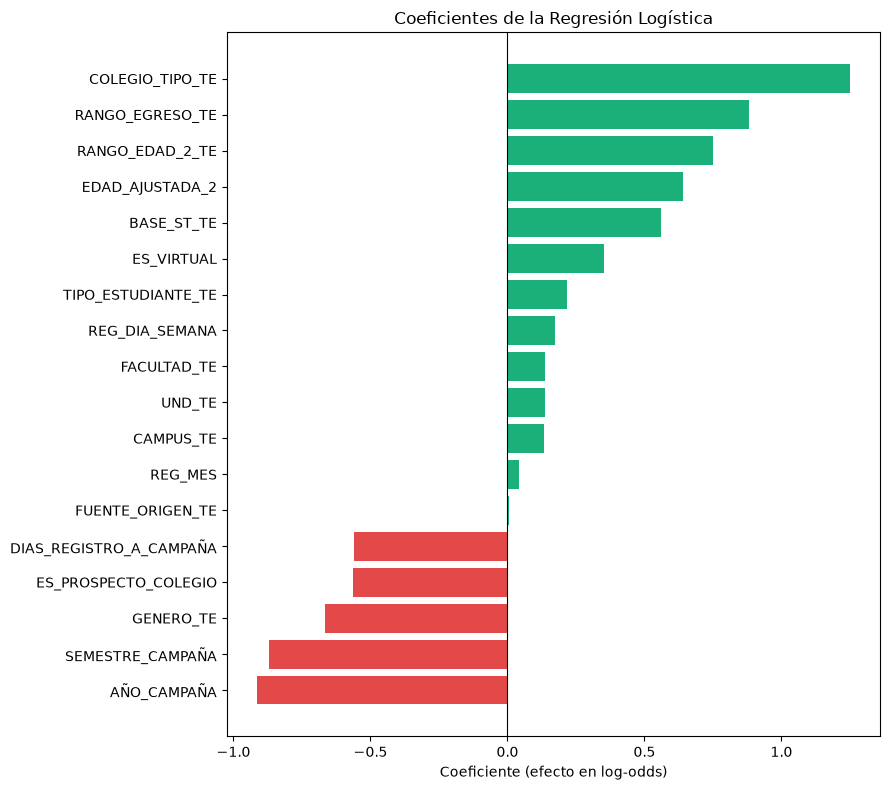

In [111]:
import matplotlib.pyplot as plt

coef_ordenado = coeficientes.sort_values(
    "coeficiente", ascending=True
)  # ascending para que el barh quede bien

colores = ["#1baf7a" if v >= 0 else "#e34948" for v in coef_ordenado["coeficiente"]]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(coef_ordenado["feature"], coef_ordenado["coeficiente"], color=colores)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coeficiente (efecto en log-odds)")
ax.set_title("Coeficientes de la Regresión Logística")
plt.tight_layout()
plt.savefig("coeficientes_lr.png", dpi=150)
plt.show()

In [112]:
# Tasa de conversión por campaña — ya la calculamos antes, la recuperamos
tendencia_campana = (
    df_prospectos_stage2.group_by(["AÑO_CAMPAÑA", "SEMESTRE_CAMPAÑA"])
    .agg(
        [
            pl.len().alias("n_total"),
            pl.col("PM").sum().alias("n_pm1"),
        ]
    )
    .with_columns(
        (pl.col("n_pm1") / pl.col("n_total") * 100).round(2).alias("tasa_pct")
    )
    .sort(["AÑO_CAMPAÑA", "SEMESTRE_CAMPAÑA"])
    .collect()
)

print(tendencia_campana)

shape: (8, 5)
┌─────────────┬──────────────────┬─────────┬───────┬──────────┐
│ AÑO_CAMPAÑA ┆ SEMESTRE_CAMPAÑA ┆ n_total ┆ n_pm1 ┆ tasa_pct │
│ ---         ┆ ---              ┆ ---     ┆ ---   ┆ ---      │
│ i16         ┆ i8               ┆ u32     ┆ i64   ┆ f64      │
╞═════════════╪══════════════════╪═════════╪═══════╪══════════╡
│ 2022        ┆ 2                ┆ 612376  ┆ 11684 ┆ 1.91     │
│ 2023        ┆ 1                ┆ 1167512 ┆ 34301 ┆ 2.94     │
│ 2023        ┆ 2                ┆ 1232154 ┆ 16487 ┆ 1.34     │
│ 2024        ┆ 1                ┆ 1434587 ┆ 39296 ┆ 2.74     │
│ 2024        ┆ 2                ┆ 1519452 ┆ 22616 ┆ 1.49     │
│ 2025        ┆ 1                ┆ 1753843 ┆ 40461 ┆ 2.31     │
│ 2025        ┆ 2                ┆ 1758329 ┆ 24568 ┆ 1.4      │
│ 2026        ┆ 1                ┆ 2201147 ┆ 45099 ┆ 2.05     │
└─────────────┴──────────────────┴─────────┴───────┴──────────┘


In [113]:
tendencia_campana_filtrado = (
    df_train_filtrado.vstack(df_test_filtrado.select(df_train_filtrado.columns))
    if "PM" in df_train_filtrado.columns
    else None
)

# Más simple: usar directamente el dataframe combinado original con el filtro aplicado
tendencia_filtrado = (
    df_prospectos_stage2.filter(
        pl.col("EDAD_AJUSTADA_2").is_not_null() | pl.col("RANGO_EGRESO").is_not_null()
    )
    .group_by(["AÑO_CAMPAÑA", "SEMESTRE_CAMPAÑA"])
    .agg(
        [
            pl.len().alias("n_total"),
            pl.col("PM").sum().alias("n_pm1"),
        ]
    )
    .with_columns(
        (pl.col("n_pm1") / pl.col("n_total") * 100).round(2).alias("tasa_pct")
    )
    .sort(["AÑO_CAMPAÑA", "SEMESTRE_CAMPAÑA"])
    .collect()
)

print(tendencia_filtrado)

shape: (8, 5)
┌─────────────┬──────────────────┬─────────┬───────┬──────────┐
│ AÑO_CAMPAÑA ┆ SEMESTRE_CAMPAÑA ┆ n_total ┆ n_pm1 ┆ tasa_pct │
│ ---         ┆ ---              ┆ ---     ┆ ---   ┆ ---      │
│ i16         ┆ i8               ┆ u32     ┆ i64   ┆ f64      │
╞═════════════╪══════════════════╪═════════╪═══════╪══════════╡
│ 2022        ┆ 2                ┆ 137899  ┆ 11684 ┆ 8.47     │
│ 2023        ┆ 1                ┆ 218776  ┆ 34301 ┆ 15.68    │
│ 2023        ┆ 2                ┆ 218333  ┆ 16487 ┆ 7.55     │
│ 2024        ┆ 1                ┆ 1434587 ┆ 39296 ┆ 2.74     │
│ 2024        ┆ 2                ┆ 1519452 ┆ 22616 ┆ 1.49     │
│ 2025        ┆ 1                ┆ 1457375 ┆ 40461 ┆ 2.78     │
│ 2025        ┆ 2                ┆ 1758329 ┆ 24568 ┆ 1.4      │
│ 2026        ┆ 1                ┆ 1131619 ┆ 45099 ┆ 3.99     │
└─────────────┴──────────────────┴─────────┴───────┴──────────┘


In [114]:
# Tasa de filtrado por campaña (qué % de la campaña original pasó el filtro)
comparacion = (
    tendencia_campana.join(
        tendencia_filtrado, on=["AÑO_CAMPAÑA", "SEMESTRE_CAMPAÑA"], suffix="_filtrado"
    )
    .with_columns(
        (pl.col("n_total_filtrado") / pl.col("n_total") * 100)
        .round(1)
        .alias("pct_retenido")
    )
    .select(
        [
            "AÑO_CAMPAÑA",
            "SEMESTRE_CAMPAÑA",
            "n_total",
            "n_total_filtrado",
            "pct_retenido",
        ]
    )
)
print(comparacion)

shape: (8, 5)
┌─────────────┬──────────────────┬─────────┬──────────────────┬──────────────┐
│ AÑO_CAMPAÑA ┆ SEMESTRE_CAMPAÑA ┆ n_total ┆ n_total_filtrado ┆ pct_retenido │
│ ---         ┆ ---              ┆ ---     ┆ ---              ┆ ---          │
│ i16         ┆ i8               ┆ u32     ┆ u32              ┆ f64          │
╞═════════════╪══════════════════╪═════════╪══════════════════╪══════════════╡
│ 2022        ┆ 2                ┆ 612376  ┆ 137899           ┆ 22.5         │
│ 2023        ┆ 1                ┆ 1167512 ┆ 218776           ┆ 18.7         │
│ 2023        ┆ 2                ┆ 1232154 ┆ 218333           ┆ 17.7         │
│ 2024        ┆ 1                ┆ 1434587 ┆ 1434587          ┆ 100.0        │
│ 2024        ┆ 2                ┆ 1519452 ┆ 1519452          ┆ 100.0        │
│ 2025        ┆ 1                ┆ 1753843 ┆ 1457375          ┆ 83.1         │
│ 2025        ┆ 2                ┆ 1758329 ┆ 1758329          ┆ 100.0        │
│ 2026        ┆ 1                ┆ 220

#### excluir 2022-2023 del entrenamiento

In [ ]:
# Redefinir el split de train/test excluyendo el período con captura parcial
df_train_filtrado_v2 = df_prospectos_stage2.filter(
    (pl.col("EDAD_AJUSTADA_2").is_not_null() | pl.col("RANGO_EGRESO").is_not_null())
    & (pl.col("AÑO_CAMPAÑA") >= 2024)
    & (pl.col("AÑO_CAMPAÑA") < 2025)
).collect()

df_test_filtrado_v2 = df_prospectos_stage2.filter(
    (pl.col("EDAD_AJUSTADA_2").is_not_null() | pl.col("RANGO_EGRESO").is_not_null())
    & (pl.col("AÑO_CAMPAÑA") >= 2025)
).collect()

print(f"Train (2024 completo): {len(df_train_filtrado_v2):,}")
print(f"Test (2025-2026): {len(df_test_filtrado_v2):,}")

print(f"\nTasa PM=1 train: {df_train_filtrado_v2['PM'].mean()*100:.2f}%")
print(f"Tasa PM=1 test: {df_test_filtrado_v2['PM'].mean()*100:.2f}%")